# NB08: RL vs DP — Per-Category Calibration and Scaling

**Goal**: Compare RL and DP on the same MDP, then show what RL can do that DP cannot:
1. **Per-category calibration** — Per-category calibration reveals fatigue heterogeneity (β_m varies by category) that changes the optimal policy.
2. **DP as a baseline** — Evaluate DP's discretized policy in the RL environment for an apples-to-apples reward comparison.
3. **Scale beyond 3 products** — DP's state space explodes with product-level actions. RL handles 15+ products in continuous state space.

**Experiments**:
1. **1 product per category** (4 actions, 7-dim state) — same 3 categories as DP, with per-category β_m. DP policy evaluated as a baseline.
2. **5 products per category** (16 actions, 31-dim state) — DP-intractable (~1.4T states). Shows RL's scaling to cross-category product selection.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from discount_engine.core.calibration import fit_logistic, evaluate_nll
from discount_engine.rl import DiscountEnv, run_rollout, action_distribution

matplotlib.rcParams.update({"font.size": 11})
%matplotlib inline

# ── Load data ──
DATA_DIR = Path("../data/processed")
txn = pd.read_parquet(DATA_DIR / "transaction_data.parquet")
products = pd.read_parquet(DATA_DIR / "product.parquet")

merged = txn.merge(
    products[["product_id", "commodity_desc", "sub_commodity_desc", "brand"]],
    on="product_id", how="left",
)
merged["discount_rate"] = (
    (merged["retail_disc"].abs() + merged["coupon_disc"].abs() + merged["coupon_match_disc"].abs())
    / merged["sales_value"].clip(lower=0.01)
).clip(0, 1)

print(f"Transactions: {len(txn):,}")
print(f"Products: {len(products):,}")

Transactions: 2,595,732
Products: 92,353


In [2]:
# ── Product selection (same products as NB05/article) ──
# NB05 manually curated products based on deal signal analysis.
# We reuse the exact same products for consistency with the article.

DP_CATEGORIES = [
    "FLUID MILK PRODUCTS",
    "ICE CREAM/MILK/SHERBTS",
    "FROZEN PIZZA",
]

# NB05's manually curated products (from Cell 11 of 05_rl_walkthrough.ipynb)
# Experiment 1: 1 product per category ("Phase 2 representative" — used in DP article)
category_products_1 = {
    "FLUID MILK PRODUCTS": [995242],
    "ICE CREAM/MILK/SHERBTS": [854042],
    "FROZEN PIZZA": [907631],
}

# Experiment 2: 5 products per category (NB05's full curated set)
category_products_5 = {
    "FLUID MILK PRODUCTS": sorted([995242, 1029743, 908531, 862349, 983584]),
    "ICE CREAM/MILK/SHERBTS": sorted([854042, 988693, 827683, 1050968, 1118033]),
    "FROZEN PIZZA": sorted([907631, 944139, 937791, 969568, 1134810]),
}

# Show selected products
for label, cp in [("Exp 1 (1/cat)", category_products_1), ("Exp 2 (5/cat)", category_products_5)]:
    print(f"── {label} ──")
    for cat in DP_CATEGORIES:
        pids = cp[cat]
        cat_data = merged[merged["commodity_desc"] == cat]
        for pid in pids:
            pid_data = cat_data[cat_data["product_id"] == pid]
            disc = pid_data["discount_rate"].median()
            price = pid_data["sales_value"].median()
            short = cat.split("/")[0]
            print(f"  {short:<20s} pid={pid}  ${price:.2f}  median_disc={disc:.3f}  n={len(pid_data)}")
    print()

── Exp 1 (1/cat) ──
  FLUID MILK PRODUCTS  pid=995242  $1.89  median_disc=0.690  n=12542
  ICE CREAM            pid=854042  $2.00  median_disc=0.495  n=299
  FROZEN PIZZA         pid=907631  $3.49  median_disc=0.086  n=857

── Exp 2 (5/cat) ──
  FLUID MILK PRODUCTS  pid=862349  $1.79  median_disc=0.617  n=4109
  FLUID MILK PRODUCTS  pid=908531  $1.50  median_disc=0.790  n=5028
  FLUID MILK PRODUCTS  pid=983584  $2.49  median_disc=0.000  n=1804
  FLUID MILK PRODUCTS  pid=995242  $1.89  median_disc=0.690  n=12542
  FLUID MILK PRODUCTS  pid=1029743  $2.52  median_disc=0.000  n=14430
  ICE CREAM            pid=827683  $1.99  median_disc=0.000  n=586
  ICE CREAM            pid=854042  $2.00  median_disc=0.495  n=299
  ICE CREAM            pid=988693  $1.99  median_disc=0.000  n=661
  ICE CREAM            pid=1050968  $1.99  median_disc=0.000  n=266
  ICE CREAM            pid=1118033  $2.50  median_disc=0.596  n=309
  FROZEN PIZZA         pid=907631  $3.49  median_disc=0.086  n=857
  FROZEN 

In [3]:
# ── Calibration helpers ──
# Using price_delta_dollars mode: deal_signal = price_gap_in_dollars when on deal.
# This is consistent with DP's deal_signal_mode and avoids the unit mismatch
# that occurs with positive_centered_anomaly.

RECENCY_SENTINEL = 52.0
DELTA = 0.30  # promotion discount depth
GLOBAL_HH_WEEKS = merged[["household_key", "week_no"]].drop_duplicates().copy()
print(f"Global HH-week universe: {len(GLOBAL_HH_WEEKS):,} rows")


def build_panel_for_category(cat, selected_pids):
    """Build household x product x week panel with price_delta_dollars deal signal."""
    cat_data = merged[merged["commodity_desc"] == cat]
    selected_txn = cat_data[cat_data["product_id"].isin(selected_pids)].copy()

    hh_weeks = GLOBAL_HH_WEEKS.copy()
    products_df = pd.DataFrame({"product_id": selected_pids})
    hh_weeks["__key"] = 1
    products_df["__key"] = 1
    grid = hh_weeks.merge(products_df, on="__key").drop(columns="__key")

    purchases = selected_txn.groupby(
        ["household_key", "week_no", "product_id"], as_index=False
    ).agg(
        purchased=("basket_id", "size"),
        hh_discount_sum=("discount_rate", "sum"),
        hh_discount_count=("discount_rate", "size"),
    )
    panel = grid.merge(purchases, on=["household_key", "week_no", "product_id"], how="left")
    panel["purchased"] = (panel["purchased"].fillna(0) > 0).astype(int)
    panel["hh_discount_sum"] = panel["hh_discount_sum"].fillna(0.0)
    panel["hh_discount_count"] = panel["hh_discount_count"].fillna(0.0)

    # price_delta_dollars: deal_signal = discount_rate * price (dollar savings)
    # Use leave-one-out discount rate, then multiply by product price
    pw_agg = selected_txn.groupby(
        ["product_id", "week_no"], as_index=False
    ).agg(total_disc_sum=("discount_rate", "sum"), total_disc_count=("discount_rate", "size"))
    panel = panel.merge(pw_agg, on=["product_id", "week_no"], how="left")
    panel["total_disc_sum"] = panel["total_disc_sum"].fillna(0.0)
    panel["total_disc_count"] = panel["total_disc_count"].fillna(0.0)

    loo_sum = panel["total_disc_sum"] - panel["hh_discount_sum"]
    loo_count = panel["total_disc_count"] - panel["hh_discount_count"]
    panel["discount_rate_loo"] = np.where(
        loo_count > 0, loo_sum / loo_count,
        np.where(panel["total_disc_count"] > 0,
                 panel["total_disc_sum"] / panel["total_disc_count"], 0.0),
    )

    # Centered anomaly in percentage, then convert to dollars
    prod_baselines = selected_txn.groupby("product_id")["discount_rate"].median().rename("prod_baseline")
    panel = panel.merge(prod_baselines, on="product_id", how="left")
    panel["prod_baseline"] = panel["prod_baseline"].fillna(0.0)
    pct_anomaly = (panel["discount_rate_loo"] - panel["prod_baseline"]).clip(lower=0.0)

    # Multiply by product price to get dollar deal signal
    prod_prices = selected_txn.groupby("product_id")["sales_value"].median().rename("prod_price")
    panel = panel.merge(prod_prices, on="product_id", how="left")
    panel["prod_price"] = panel["prod_price"].fillna(1.0)
    panel["deal_signal"] = pct_anomaly * panel["prod_price"]

    pid_to_idx = {pid: idx for idx, pid in enumerate(selected_pids)}
    panel["prod_idx"] = panel["product_id"].map(pid_to_idx)
    panel = panel.sort_values(["household_key", "prod_idx", "week_no"]).reset_index(drop=True)
    return panel


def compute_recency(panel):
    """Weeks since last purchase within each HH-product sequence."""
    recency = np.full(len(panel), RECENCY_SENTINEL, dtype=float)
    weeks = panel["week_no"].to_numpy(dtype=float)
    purchased = panel["purchased"].to_numpy(dtype=int)
    keys = panel[["household_key", "prod_idx"]].to_numpy()
    is_start = np.ones(len(panel), dtype=bool)
    is_start[1:] = np.any(keys[1:] != keys[:-1], axis=1)
    starts = np.flatnonzero(is_start)
    ends = np.concatenate([starts[1:], [len(panel)]])
    for s, e in zip(starts, ends):
        last_t = None
        for i in range(s, e):
            if last_t is not None:
                recency[i] = max(0.0, weeks[i] - last_t)
            if purchased[i]:
                last_t = weeks[i]
    return recency


def compute_memory(panel, alpha):
    """Gap-aware EWMA memory using deal_signal (in dollars)."""
    memory = np.zeros(len(panel), dtype=float)
    weeks = panel["week_no"].to_numpy(dtype=float)
    signal = panel["deal_signal"].to_numpy(dtype=float)
    keys = panel[["household_key", "prod_idx"]].to_numpy()
    is_start = np.ones(len(panel), dtype=bool)
    is_start[1:] = np.any(keys[1:] != keys[:-1], axis=1)
    starts = np.flatnonzero(is_start)
    ends = np.concatenate([starts[1:], [len(panel)]])
    for s, e in zip(starts, ends):
        m = 0.0
        prev_w = None
        for i in range(s, e):
            if prev_w is not None:
                gap = max(1.0, weeks[i] - prev_w)
                m = m * (alpha ** gap)
            m += signal[i]
            memory[i] = m
            prev_w = weeks[i]
    return memory


def calibrate_category(cat, selected_pids, alpha_candidates=None):
    """Per-category calibration with price_delta_dollars deal signal."""
    if alpha_candidates is None:
        alpha_candidates = [0.95, 0.99, 0.90, 0.85, 0.80, 0.70, 0.50]

    panel = build_panel_for_category(cat, selected_pids)
    n_products = len(selected_pids)

    panel["recency"] = compute_recency(panel)
    y = panel["purchased"].to_numpy(dtype=float)
    deal = panel["deal_signal"].to_numpy(dtype=float)
    recency_arr = panel["recency"].to_numpy(dtype=float)
    cat_idx = panel["prod_idx"].to_numpy(dtype=int)
    weeks = panel["week_no"].to_numpy(dtype=float)

    cutoff = float(np.quantile(weeks[np.isfinite(weeks)], 0.80))
    train_mask = weeks <= cutoff
    val_mask = weeks > cutoff

    best_val = np.inf
    best_result = None

    for alpha in alpha_candidates:
        memory = compute_memory(panel, alpha)
        intercepts, bp, bl, bm, train_nll = fit_logistic(
            y[train_mask], cat_idx[train_mask], deal[train_mask],
            recency_arr[train_mask], memory[train_mask], n_cats=n_products,
        )
        val_nll = evaluate_nll(
            y[val_mask], cat_idx[val_mask], deal[val_mask],
            recency_arr[val_mask], memory[val_mask],
            intercepts, bp, bl, bm,
        )
        if val_nll < best_val:
            best_val = val_nll
            best_result = {
                "alpha": alpha, "beta_p": bp, "beta_l": bl, "beta_m": bm,
                "train_nll": train_nll, "val_nll": val_nll,
                "intercepts": intercepts,
                "panel_size": len(panel),
                "purchase_rate": float(y.mean()),
            }

    return best_result

print("Calibration helpers ready (price_delta_dollars mode).")

Global HH-week universe: 123,976 rows
Calibration helpers ready (price_delta_dollars mode).


In [4]:
# ── Per-category calibration at α=0.80 ──
# Validation NLL is largely flat across α ∈ [0.80, 0.95] (see NB07).
# We use α=0.80 for its shorter half-life (~3 weeks vs ~14 weeks at α=0.95),
# which is more plausible for weekly grocery purchase memory and gives both
# DP and RL more dynamic range in the memory dimension.
import pickle, time

CACHE_DIR = Path("../runs/nb08_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

calibrations = {}  # n_per_cat -> {cat -> result}

for n_per_cat, cat_prods in [(1, category_products_1), (5, category_products_5)]:
    cache_path = CACHE_DIR / f"calibration_n{n_per_cat}_alpha0.80.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            calibrations[n_per_cat] = pickle.load(f)
        print(f"Loaded cached calibration for n={n_per_cat}")
    else:
        t0 = time.perf_counter()
        results = {}
        for cat in DP_CATEGORIES:
            pids = cat_prods[cat]
            result = calibrate_category(cat, pids, alpha_candidates=[0.80])
            results[cat] = result
            short = cat.split("/")[0].split(" - ")[0]
            print(f"  n={n_per_cat} {short:<15s} β_m={result['beta_m']:.4f}  β_p={result['beta_p']:.4f}")
        calibrations[n_per_cat] = results
        with open(cache_path, "wb") as f:
            pickle.dump(results, f)
        print(f"  Done in {time.perf_counter()-t0:.1f}s")

print("\n── Per-Category β_m (α=0.80) vs DP's Pooled β_m ──")
print(f"  DP pooled:   β_m = 1e-6 (fatigue invisible)")
for cat in DP_CATEGORIES:
    short = cat.split("/")[0].split(" - ")[0]
    r1 = calibrations[1][cat]
    print(f"  {short:<20s} β_m = {r1['beta_m']:.4f}  β_p = {r1['beta_p']:.4f}")

Loaded cached calibration for n=1
Loaded cached calibration for n=5

── Per-Category β_m (α=0.80) vs DP's Pooled β_m ──
  DP pooled:   β_m = 1e-6 (fatigue invisible)
  FLUID MILK PRODUCTS  β_m = 0.9387  β_p = 5.0152
  ICE CREAM            β_m = 0.8205  β_p = 2.7108
  FROZEN PIZZA         β_m = 0.4083  β_p = 0.9553


In [5]:
# ── Run DP with per-category β_m ──
from discount_engine.core.params import MDPParams, CategoryParams
from discount_engine.dp.value_iteration import ValueIterationConfig, solve_value_iteration
from discount_engine.dp.policy import build_evaluation_summary, policy_rows
from discount_engine.dp.discretization import (
    bucketize_churn, bucketize_memory, bucketize_recency,
    configure_bucket_grids, MEMORY_GRID, RECENCY_GRID, resolve_churn_grid,
)
from discount_engine.core.types import DiscreteState

# Widen memory grid for dollar-denominated memory.
# Default grid (0.0, 0.9, 2.0) was designed for proportion-based memory.
# With price_delta_dollars, steady-state memory ranges from $2.84 (FM) to $5.24 (FP).
configure_bucket_grids(memory_grid=(0.0, 1.5, 4.0))
print(f"Memory grid set to {MEMORY_GRID}")

# Shared constants
ALPHA = 0.80
V2_C0 = 0.014
V2_ETA = 0.002

cal_1 = calibrations[1]

dp_with_percat = MDPParams(
    delta=DELTA,
    gamma=0.99,
    alpha=ALPHA,
    beta_p=0.0,   # overridden per-category
    beta_l=0.0,   # overridden per-category
    beta_m=0.0,   # overridden per-category
    eta=V2_ETA,
    c0=V2_C0,
    categories=tuple(
        CategoryParams(
            name=cat,
            price=float(merged[merged["product_id"] == category_products_1[cat][0]]["sales_value"].median()),
            beta_0=float(cal_1[cat]["intercepts"][0]),
            # price_delta_dollars: promotion_deal_signal = price * delta
            promotion_deal_signal=float(
                merged[merged["product_id"] == category_products_1[cat][0]]["sales_value"].median() * DELTA
            ),
            beta_m=cal_1[cat]["beta_m"],
            beta_p=cal_1[cat]["beta_p"],
            beta_l=cal_1[cat]["beta_l"],
        )
        for cat in DP_CATEGORIES
    ),
    metadata={
        "deal_signal_mode": "price_delta_dollars",
        # Tighten churn grid: with eta=0.002 and gradual recovery,
        # churn stays in ~[0.01, 0.15]. Default (0.05, 0.50) wastes resolution.
        "churn_grid": [0.03, 0.10],
    },
)

# Show what DP sees
print("── DP with Per-Category Calibration (α=0.80, price_delta_dollars) ──")
print(f"  Churn grid: {resolve_churn_grid(dp_with_percat)}")
for cat_p in dp_with_percat.categories:
    short = cat_p.name.split("/")[0].split(" - ")[0]
    boost = cat_p.beta_p * cat_p.promotion_deal_signal
    print(f"  {short:<20s} β_m={cat_p.beta_m:.4f}  β_p={cat_p.beta_p:.4f}  "
          f"deal_sig=${cat_p.promotion_deal_signal:.3f}  logit_boost={boost:.2f}  price=${cat_p.price:.2f}")

# Solve
config = ValueIterationConfig(gamma=0.99, epsilon=1e-8, max_iters=10000, show_progress=True)
result = solve_value_iteration(params=dp_with_percat, config=config)
print(f"\nConverged: {result.converged}, iterations: {result.iterations}")

# Policy summary
rows = policy_rows(policy=result.policy, values=result.values, params=dp_with_percat)
eval_summary = build_evaluation_summary(rows)

action_hist = eval_summary["policy_cluster_summary"]["action_histogram"]
action_map = {0: "No-promo"}
for i, cat_p in enumerate(dp_with_percat.categories):
    action_map[i+1] = cat_p.name.split("/")[0].split(" - ")[0]

print(f"\n── DP Policy ──")
total = sum(int(v) for v in action_hist.values())
for action_str, count in sorted(action_hist.items(), key=lambda x: -int(x[1])):
    action_idx = int(action_str)
    name = action_map.get(action_idx, f"action_{action_idx}")
    print(f"  {name}: {int(count)/total:.1%} of states ({count}/{total})")

print(f"\n── By Churn Bucket ──")
for bucket, info in eval_summary["policy_cluster_summary"]["by_churn_bucket"].items():
    label = ["Engaged", "At-Risk"][int(bucket)]
    actions = info["action_histogram"]
    top_action = max(actions, key=lambda k: actions[k])
    top_name = action_map.get(int(top_action), f"action_{top_action}")
    print(f"  {label}: {top_name} ({int(actions[top_action])/int(info['count']):.0%})")


# ── DP policy wrapper for RL env evaluation ──
def make_dp_policy_fn(dp_policy, dp_params):
    """Create a callable that maps RL continuous obs → DP action."""
    churn_grid = resolve_churn_grid(dp_params)
    N = len(dp_params.categories)

    def dp_policy_fn(obs):
        churn = obs[0]
        memory = obs[1:1+N]
        recency = obs[1+N:1+2*N]
        state = DiscreteState(
            churn_bucket=bucketize_churn(float(churn), churn_grid=churn_grid),
            memory_buckets=tuple(bucketize_memory(float(m)) for m in memory),
            recency_buckets=tuple(bucketize_recency(float(r)) for r in recency),
        )
        return dp_policy.get(state, 0)

    return dp_policy_fn

dp_policy_fn = make_dp_policy_fn(result.policy, dp_with_percat)
print("\nDP policy function ready for RL env evaluation.")

Memory grid set to (0.0, 0.9, 2.0)
── DP with Per-Category Calibration (α=0.80, price_delta_dollars) ──
  Churn grid: (0.03, 0.1)
  FLUID MILK PRODUCTS  β_m=0.9387  β_p=5.0152  deal_sig=$0.567  logit_boost=2.84  price=$1.89
  ICE CREAM            β_m=0.8205  β_p=2.7108  deal_sig=$0.600  logit_boost=1.63  price=$2.00
  FROZEN PIZZA         β_m=0.4083  β_p=0.9553  deal_sig=$1.047  logit_boost=1.00  price=$3.49


Value Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]


Converged: True, iterations: 520

── DP Policy ──
  FLUID MILK PRODUCTS: 66.7% of states (288/432)
  No-promo: 22.2% of states (96/432)
  ICE CREAM: 11.1% of states (48/432)

── By Churn Bucket ──
  Engaged: FLUID MILK PRODUCTS (67%)
  At-Risk: FLUID MILK PRODUCTS (67%)

DP policy function ready for RL env evaluation.


In [6]:
# ── Build env factory (RL) ──
# Uses price * delta as deal signal, consistent with calibration and DP.
from discount_engine.rl.rollout import run_rollout


def build_env(cat_prods, n_per_cat, decouple_memory_init=True, init_memory_frac=0.3):
    """Create env with per-category calibrated params at α=0.80, price_delta_dollars."""
    cal = calibrations[n_per_cat]

    product_ids, beta_0_list, beta_m_list, beta_p_list, beta_l_list = [], [], [], [], []
    categories, prices, deal_signals = [], [], []

    for cat in DP_CATEGORIES:
        pids = cat_prods[cat]
        r = cal[cat]
        for i, pid in enumerate(pids):
            product_ids.append(pid)
            beta_0_list.append(r["intercepts"][i])
            beta_m_list.append(r["beta_m"])
            beta_p_list.append(r["beta_p"])
            beta_l_list.append(r["beta_l"])
            categories.append(cat)
            pid_txn = merged[merged["product_id"] == pid]
            price = float(pid_txn["sales_value"].median())
            prices.append(price)
            # price_delta_dollars: deal_signal = price * delta
            deal_signals.append(price * DELTA)

    pp = {}
    for i, pid in enumerate(product_ids):
        pp[pid] = {
            "beta_0": beta_0_list[i],
            "raw_deal_signal": deal_signals[i],
            "price": prices[i],
            "category": categories[i],
        }

    return DiscountEnv(
        product_params=pp, product_order=product_ids,
        beta_p=np.array(beta_p_list), beta_l=np.array(beta_l_list),
        beta_m=np.array(beta_m_list), alpha=ALPHA,
        c0=V2_C0, eta=V2_ETA, churn_cost=0.0,
        decouple_memory_init=decouple_memory_init,
        init_memory_frac=init_memory_frac,
    )


# Sanity check
for n, cp in [(1, category_products_1), (5, category_products_5)]:
    env = build_env(cp, n)
    print(f"n={n}: {env.N} products, dim={env.observation_space.shape[0]}, "
          f"actions={env.action_space.n}, memory_cap={env._memory_cap:.2f}")
    for j in range(env.N):
        pid = env.products[j]
        p = env.params[pid]
        bm = env.beta_m[j] if hasattr(env.beta_m, '__len__') else env.beta_m
        bp = env.beta_p[j] if hasattr(env.beta_p, '__len__') else env.beta_p
        short = p["category"].split("/")[0].split(" - ")[0]
        boost = bp * p["raw_deal_signal"]
        print(f"  [{j}] {short:<15s} ${p['price']:.2f}  deal=${p['raw_deal_signal']:.3f}  "
              f"β_m={bm:.3f}  β_p={bp:.3f}  boost={boost:.2f}")
    print()

n=1: 3 products, dim=7, actions=4, memory_cap=5.23
  [0] FLUID MILK PRODUCTS $1.89  deal=$0.567  β_m=0.939  β_p=5.015  boost=2.84
  [1] ICE CREAM       $2.00  deal=$0.600  β_m=0.821  β_p=2.711  boost=1.63
  [2] FROZEN PIZZA    $3.49  deal=$1.047  β_m=0.408  β_p=0.955  boost=1.00

n=5: 15 products, dim=31, actions=16, memory_cap=6.00
  [0] FLUID MILK PRODUCTS $1.79  deal=$0.537  β_m=0.240  β_p=1.539  boost=0.83
  [1] FLUID MILK PRODUCTS $1.50  deal=$0.450  β_m=0.240  β_p=1.539  boost=0.69
  [2] FLUID MILK PRODUCTS $2.49  deal=$0.747  β_m=0.240  β_p=1.539  boost=1.15
  [3] FLUID MILK PRODUCTS $1.89  deal=$0.567  β_m=0.240  β_p=1.539  boost=0.87
  [4] FLUID MILK PRODUCTS $2.52  deal=$0.756  β_m=0.240  β_p=1.539  boost=1.16
  [5] ICE CREAM       $1.99  deal=$0.597  β_m=0.247  β_p=1.190  boost=0.71
  [6] ICE CREAM       $2.00  deal=$0.600  β_m=0.247  β_p=1.190  boost=0.71
  [7] ICE CREAM       $1.99  deal=$0.597  β_m=0.247  β_p=1.190  boost=0.71
  [8] ICE CREAM       $1.99  deal=$0.597  β_m

In [46]:
# ── Product-level break-even analysis (for article table) ──
import scipy.special

env1 = build_env(category_products_1, 1)
BREAK_EVEN_LIFT = 1 / (1 - DELTA)  # 1.4286 for δ=0.30

print(f"Break-even volume lift required at δ={DELTA:.0%}: {BREAK_EVEN_LIFT:.2f}x ({(BREAK_EVEN_LIFT-1)*100:.1f}%)\n")
print(f"{'Product':<20s} {'Price':>6s}  {'P(no promo)':>11s}  {'P(promo)':>9s}  {'Lift':>7s}  {'Break-even?'}")
print("-" * 75)

for j in range(env1.N):
    pid = env1.products[j]
    p = env1.params[pid]
    short = p["category"].split("/")[0].split(" - ")[0]
    price = p["price"]
    b0 = env1._beta_0[j]
    bp = env1.beta_p[j]
    deal = p["raw_deal_signal"]

    # P(buy | no promo) = σ(β_0), P(buy | promo) = σ(β_0 + β_p × deal_signal)
    p_no_promo = scipy.special.expit(b0)
    p_promo = scipy.special.expit(b0 + bp * deal)
    lift = p_promo / p_no_promo

    # Revenue comparison: rev_no_promo = price * P(no promo), rev_promo = price*(1-δ) * P(promo)
    rev_no = price * p_no_promo
    rev_promo = price * (1 - DELTA) * p_promo
    breaks_even = rev_promo > rev_no

    print(f"{short:<20s} ${price:>5.2f}  {p_no_promo:>10.1%}  {p_promo:>9.1%}  {lift:>6.2f}x  {'✓ YES' if breaks_even else '✗ NO'}")

print(f"\n(Revenue break-even: price×(1-δ)×P(promo) > price×P(no promo), i.e. lift > {BREAK_EVEN_LIFT:.2f}x)")

Break-even volume lift required at δ=30%: 1.43x (42.9%)

Product               Price  P(no promo)   P(promo)     Lift  Break-even?
---------------------------------------------------------------------------
FLUID MILK PRODUCTS  $ 1.89       23.4%      84.0%    3.58x  ✓ YES
ICE CREAM            $ 2.00        2.4%      10.9%    4.64x  ✓ YES
FROZEN PIZZA         $ 3.49       10.7%      24.7%    2.30x  ✓ YES

(Revenue break-even: price×(1-δ)×P(promo) > price×P(no promo), i.e. lift > 1.43x)


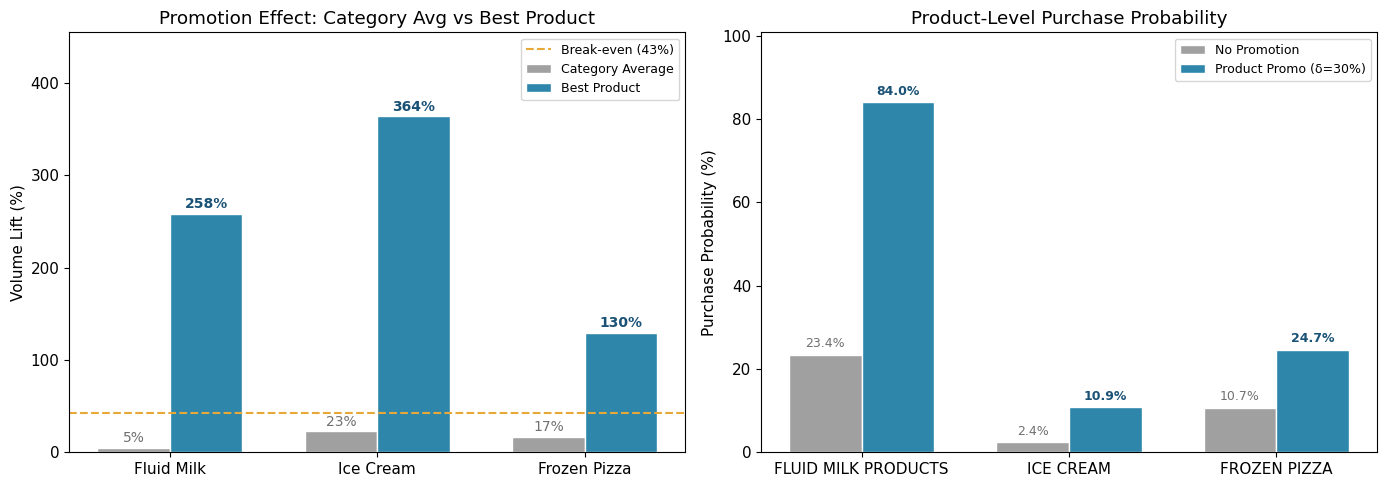

Saved: submissions/dp_breakeven_analysis.png


In [51]:
# ── DP Charts: Category vs Product Lift + Product Purchase Probability ──
import matplotlib.pyplot as plt
import scipy.special

C_GRAY = "#A0A0A0"   # no promo / category average (consistent across both)
C_BLUE = "#2E86AB"   # best product / product promo (consistent across both)

# Category-level data (from Phase 2 / mdp_params.yaml calibration)
cat_data = {
    "Fluid Milk":   {"price": 2.49, "p_no": 0.817, "p_promo": 0.857},
    "Ice Cream":    {"price": 2.59, "p_no": 0.304, "p_promo": 0.373},
    "Frozen Pizza":  {"price": 2.00, "p_no": 0.324, "p_promo": 0.378},
}

# Product-level data (from NB08 per-category calibration)
env1 = build_env(category_products_1, 1)
products = []
p_no_list, p_promo_list = [], []
for j in range(env1.N):
    pid = env1.products[j]
    p = env1.params[pid]
    short = p["category"].split("/")[0].split(" - ")[0]
    b0 = env1._beta_0[j]
    bp = env1.beta_p[j]
    deal = p["raw_deal_signal"]
    products.append(short)
    p_no_list.append(scipy.special.expit(b0))
    p_promo_list.append(scipy.special.expit(b0 + bp * deal))

categories = ["Fluid Milk", "Ice Cream", "Frozen Pizza"]
cat_lifts = [(cat_data[c]["p_promo"] / cat_data[c]["p_no"] - 1) * 100 for c in categories]
prod_lifts = [(p_promo_list[j] / p_no_list[j] - 1) * 100 for j in range(len(products))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Category Average vs Best Product Lift ──
x = np.arange(len(categories))
w = 0.35
bars1 = ax1.bar(x - w/2, cat_lifts, w, label="Category Average", color=C_GRAY, edgecolor="white")
bars2 = ax1.bar(x + w/2, prod_lifts, w, label="Best Product", color=C_BLUE, edgecolor="white")
ax1.set_ylabel("Volume Lift (%)")
ax1.set_title("Promotion Effect: Category Avg vs Best Product")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.axhline(y=42.9, color="#E8A838", linestyle="--", linewidth=1.5, label="Break-even (43%)")
ax1.legend(fontsize=9)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=10, color="#707070")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=10, color="#1a5276", fontweight="bold")
ax1.set_ylim(0, max(prod_lifts) * 1.25)

# ── Right: Product-Level Purchase Probability (No Promo vs Promo) ──
x2 = np.arange(len(products))
p_no_pct = [v * 100 for v in p_no_list]
p_promo_pct = [v * 100 for v in p_promo_list]
bars3 = ax2.bar(x2 - w/2, p_no_pct, w, label="No Promotion", color=C_GRAY, edgecolor="white")
bars4 = ax2.bar(x2 + w/2, p_promo_pct, w, label="Product Promo (δ=30%)", color=C_BLUE, edgecolor="white")
ax2.set_ylabel("Purchase Probability (%)")
ax2.set_title("Product-Level Purchase Probability")
ax2.set_xticks(x2)
ax2.set_xticklabels(products)
ax2.legend(fontsize=9)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9, color="#707070")
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9, color="#1a5276", fontweight="bold")
ax2.set_ylim(0, max(p_promo_pct) * 1.2)

plt.tight_layout()
plt.savefig("../submissions/dp_breakeven_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: submissions/dp_breakeven_analysis.png")

In [65]:
# ── Training infrastructure (same as NB07) ──
import torch
import hashlib
import tempfile
from discount_engine.rl.agent import DQNAgent
from discount_engine.rl.train import Trainer


def _cache_key(**kwargs) -> str:
    raw = str(sorted(kwargs.items()))
    return hashlib.sha256(raw.encode()).hexdigest()[:12]


def save_training_cache(label: str, agent, metrics: dict, config: dict,
                        best_q_net_state=None):
    key = _cache_key(**config)
    path = CACHE_DIR / f"{label}_{key}.pt"
    payload = {
        "q_net": agent.q_net.state_dict(),
        "target_net": agent.target_net.state_dict(),
        "step_count": agent.step_count,
        "config": config,
        "metrics": {k: v.tolist() if hasattr(v, 'tolist') else v
                    for k, v in metrics.items() if k != "snapshot_paths"},
    }
    if best_q_net_state is not None:
        payload["best_q_net"] = best_q_net_state
    torch.save(payload, path)
    print(f"  Cached → {path.name}")


def load_training_cache(label: str, agent, config: dict,
                        use_best: bool = True) -> dict | None:
    key = _cache_key(**config)
    path = CACHE_DIR / f"{label}_{key}.pt"
    if not path.exists():
        return None
    data = torch.load(path, weights_only=False)
    # Prefer best checkpoint if available
    if use_best and "best_q_net" in data:
        agent.q_net.load_state_dict(data["best_q_net"])
        print(f"  Loaded BEST model ← {path.name}")
    else:
        agent.q_net.load_state_dict(data["q_net"])
        print(f"  Loaded final model ← {path.name} (step {data['step_count']:,})")
    agent.target_net.load_state_dict(agent.q_net.state_dict())
    agent.step_count = data.get("step_count", 0)
    metrics = {}
    for k, v in data["metrics"].items():
        metrics[k] = np.array(v) if isinstance(v, list) else v
    return metrics


def train_or_load(env, label: str, n_episodes: int, eval_interval: int,
                  eval_episodes: int = 50, seed: int = 42,
                  eps_decay_steps: int = 100_000, buffer_size: int = 100_000,
                  reward_scale: float = 10.0, grad_clip: float = 1.0,
                  update_every: int = 4, per_alpha: float = 0.6,
                  hidden: int = 64, extra_config: dict | None = None,
                  force_retrain: bool = False):
    """Train DQN or load from cache. Saves best checkpoint by eval reward."""
    config = {
        "n_products": env.N,
        "alpha": float(env.alpha),
        "churn_cost": float(env.churn_cost),
        "n_episodes": n_episodes,
        "seed": seed,
        "eps_decay_steps": eps_decay_steps,
        "buffer_size": buffer_size,
        "reward_scale": reward_scale,
        "grad_clip": grad_clip,
        "update_every": update_every,
        "per_alpha": per_alpha,
        "hidden": hidden,
        **(extra_config or {}),
    }

    agent = DQNAgent(
        obs_dim=env.observation_space.shape[0],
        n_actions=env.action_space.n,
        obs_scale=env.build_obs_scale(),
        eps_decay_steps=eps_decay_steps,
        buffer_size=buffer_size,
        reward_scale=reward_scale,
        grad_clip=grad_clip,
        per_alpha=per_alpha,
        hidden=hidden,
    )

    if not force_retrain:
        cached = load_training_cache(label, agent, config)
        if cached is not None:
            return agent, cached

    # Train with snapshot dir so we can recover best checkpoint
    snap_dir = CACHE_DIR / f"snapshots_{label}"
    trainer = Trainer(env, agent, seed=seed, label=label,
                      update_every=update_every, snapshot_dir=snap_dir)
    metrics = trainer.train(
        n_episodes=n_episodes,
        eval_interval=eval_interval,
        eval_episodes=eval_episodes,
    )

    # Find best checkpoint by eval reward
    best_q_net_state = None
    if "eval_rewards" in metrics and "snapshot_paths" in metrics:
        eval_rewards = metrics["eval_rewards"]
        snapshot_paths = metrics["snapshot_paths"]
        n = min(len(eval_rewards), len(snapshot_paths))
        if n > 0:
            best_idx = int(np.argmax(eval_rewards[:n]))
            best_path = Path(snapshot_paths[best_idx])
            if best_path.exists():
                best_data = torch.load(best_path, weights_only=False)
                best_q_net_state = best_data["q_net"]
                best_ep = metrics.get("eval_points", list(range(n)))[best_idx]
                best_reward = eval_rewards[best_idx]
                print(f"  Best eval reward: {best_reward:.2f} at ep {best_ep}")
                # Restore best model into agent
                agent.q_net.load_state_dict(best_q_net_state)
                agent.target_net.load_state_dict(best_q_net_state)

    save_training_cache(label, agent, metrics, config, best_q_net_state=best_q_net_state)

    # Clean up snapshot files
    import shutil
    if snap_dir.exists():
        shutil.rmtree(snap_dir)

    return agent, metrics

print("Training infrastructure ready.")

Training infrastructure ready.


## Experiment 1: Single-Product DQN vs DP (Per-Category Calibration)

Same 3 categories as DP (FM, IC, FP), 1 product each, with **per-category β_m** from calibration at α=0.80. DP's policy is evaluated in the RL environment as a baseline, giving an apples-to-apples comparison of DP (discretized tabular) vs DQN (continuous function approximation).

In [ ]:
# ── Shared experiment runner ──

N_EVAL_ROLLOUT = 500


def collect_obs_action_pairs(env, policy_fn, n_episodes=500, seed_base=9999):
    """Run rollouts and collect (obs, action) pairs for heatmaps."""
    pairs = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed_base + ep)
        done = False
        while not done:
            a = policy_fn(obs)
            pairs.append((obs.copy(), a))
            obs, r, term, trunc, info = env.step(a)
            done = term or trunc
    return pairs


def run_experiment(env_fn, label, n_episodes=10_000,
                   eps_decay_steps=50_000, hidden=128,
                   dp_policy_fn=None):
    """Train DQN + baselines + rotation analysis.
    env_fn: callable(decouple_memory_init, init_memory_frac) -> DiscountEnv
    dp_policy_fn: optional callable(obs) -> action for DP baseline
    """
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    env_train = env_fn(decouple_memory_init=True, init_memory_frac=0.3)
    env_eval = env_fn(decouple_memory_init=False)
    N = env_train.N

    # Derive category list from env
    env_categories = list(dict.fromkeys(
        env_eval.params[env_eval.products[j]]["category"] for j in range(N)
    ))

    # ── Baselines ──
    no_promo_stats = run_rollout(env_eval, n_episodes=N_EVAL_ROLLOUT, policy='no_promo', seed=99)
    random_stats = run_rollout(env_eval, n_episodes=N_EVAL_ROLLOUT, policy='random', seed=99)

    expected_rev = (
        1 / (1 + np.exp(-(env_eval._beta_0 + env_eval.beta_p * env_eval._raw_deal_signal)))
    ) * env_eval._prices
    myopic_action = int(expected_rev.argmax()) + 1
    myopic_cat = env_eval.params[env_eval.products[myopic_action - 1]]["category"]
    myopic_stats = run_rollout(env_eval, n_episodes=N_EVAL_ROLLOUT, policy=myopic_action, seed=99)

    # DP baseline (if provided)
    dp_stats = None
    dp_obs_actions = []
    if dp_policy_fn is not None:
        dp_stats = run_rollout(env_eval, n_episodes=N_EVAL_ROLLOUT, policy=dp_policy_fn, seed=99)
        dp_obs_actions = collect_obs_action_pairs(env_eval, dp_policy_fn,
                                                  n_episodes=N_EVAL_ROLLOUT)

    print(f"\n  ── Baselines ──")
    print(f"  No-promo:       {no_promo_stats['rewards'].mean():.2f}")
    print(f"  Random:         {random_stats['rewards'].mean():.2f}")
    print(f"  Greedy-myopic:  {myopic_stats['rewards'].mean():.2f}  (always {myopic_cat.split('/')[0]})")
    if dp_stats is not None:
        print(f"  DP policy:      {dp_stats['rewards'].mean():.2f}")

    # ── Train DQN ──
    agent, metrics = train_or_load(
        env_train, label=label,
        n_episodes=n_episodes, eval_interval=500,
        eps_decay_steps=eps_decay_steps, buffer_size=max(100_000, n_episodes * 40),
        hidden=hidden,
    )

    # ── DQN eval + per-episode data ──
    ep_rewards, ep_actions, ep_mems = [], [], []
    dqn_obs_actions = []
    for ep in range(N_EVAL_ROLLOUT):
        obs, _ = env_eval.reset(seed=9999 + ep)
        acts, mems = [], [obs[1:1+N].copy()]
        total_r = 0.0
        done = False
        while not done:
            a = agent.select_action(obs, greedy=True)
            dqn_obs_actions.append((obs.copy(), a))
            obs, r, term, trunc, info = env_eval.step(a)
            acts.append(a)
            mems.append(obs[1:1+N].copy())
            total_r += r
            done = term or trunc
        ep_rewards.append(total_r)
        ep_actions.append(np.array(acts))
        ep_mems.append(np.array(mems))

    dqn_mean = np.mean(ep_rewards)
    dqn_se = np.std(ep_rewards) / np.sqrt(N_EVAL_ROLLOUT)

    print(f"\n  ── Final Results ──")
    print(f"  No-promo:       {no_promo_stats['rewards'].mean():.2f}")
    print(f"  Random:         {random_stats['rewards'].mean():.2f}")
    print(f"  Greedy-myopic:  {myopic_stats['rewards'].mean():.2f}")
    if dp_stats is not None:
        print(f"  DP policy:      {dp_stats['rewards'].mean():.2f}")
    print(f"  DQN:            {dqn_mean:.2f} ± {dqn_se:.2f}")

    # ── Action distribution by category ──
    all_acts_flat = np.concatenate(ep_actions)
    action_counts = np.bincount(all_acts_flat, minlength=N + 1).astype(float)
    action_pct = action_counts / action_counts.sum() * 100

    cat_pct = {"No-promo": action_pct[0]}
    for cat in env_categories:
        cat_indices = [j for j in range(N) if env_eval.params[env_eval.products[j]]["category"] == cat]
        cat_pct[cat.split("/")[0].split(" - ")[0]] = sum(action_pct[j+1] for j in cat_indices)

    print(f"\n  ── Action Distribution (by category) ──")
    for name, pct in cat_pct.items():
        print(f"  {name}: {pct:.1f}%")

    # ── Rotation analysis ──
    entropies, repeats, uniques = [], [], []
    for seq in ep_actions:
        counts = np.bincount(seq, minlength=N + 1)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(-np.sum(probs * np.log2(probs)))
        if len(seq) >= 2:
            repeats.append(np.sum(seq[1:] == seq[:-1]) / (len(seq) - 1))
        uniques.append(len(set(seq)))

    max_ent = np.log2(N + 1)
    print(f"\n  ── Rotation Analysis ──")
    print(f"  Entropy: {np.mean(entropies):.3f} / {max_ent:.3f} ({np.mean(entropies)/max_ent:.1%} of max)")
    print(f"  Repeat rate: {np.mean(repeats):.3f}")
    print(f"  Unique actions/ep: {np.mean(uniques):.1f} / {N + 1}")

    # Switch rate after high vs low memory
    all_mem_at_switch = []
    for acts, mems in zip(ep_actions, ep_mems):
        for t in range(1, len(acts)):
            if acts[t] != acts[t-1] and acts[t-1] > 0:
                all_mem_at_switch.append(("switch", mems[t][acts[t-1] - 1]))
            elif acts[t] == acts[t-1] and acts[t] > 0:
                all_mem_at_switch.append(("stay", mems[t][acts[t] - 1]))

    rotation_delta = 0.0
    if len(all_mem_at_switch) > 10:
        switch_df = pd.DataFrame(all_mem_at_switch, columns=["type", "memory"])
        median_mem = switch_df["memory"].median()
        high_mask = switch_df["memory"] >= median_mem
        low_mask = switch_df["memory"] < median_mem
        if high_mask.sum() > 0 and low_mask.sum() > 0:
            switch_after_high = (switch_df.loc[high_mask, "type"] == "switch").mean()
            switch_after_low = (switch_df.loc[low_mask, "type"] == "switch").mean()
            rotation_delta = switch_after_high - switch_after_low
            print(f"  Rotation Δ = {rotation_delta:+.1%}")
        else:
            print(f"  Repeat rate {np.mean(repeats):.1%} → NO ROTATION")
    else:
        print(f"  Repeat rate {np.mean(repeats):.1%} → NO ROTATION")

    return {
        "no_promo": no_promo_stats['rewards'].mean(),
        "random": random_stats['rewards'].mean(),
        "myopic": myopic_stats['rewards'].mean(),
        "dp": dp_stats['rewards'].mean() if dp_stats is not None else None,
        "dqn": dqn_mean, "dqn_se": dqn_se,
        "rotation_delta": rotation_delta,
        "action_pct": action_pct, "cat_pct": cat_pct,
        "entropy": np.mean(entropies),
        "repeat_rate": np.mean(repeats),
        "n_products": N,
        "dqn_obs_actions": dqn_obs_actions,
        "dp_obs_actions": dp_obs_actions,
    }


# ── Experiment 1: 1 product per category, per-category calibration, α=0.80 ──
exp1_result = run_experiment(
    env_fn=lambda **kw: build_env(category_products_1, 1, **kw),
    label="percat_3prod_a0.80",
    n_episodes=10_000, eps_decay_steps=50_000, hidden=128,
    dp_policy_fn=dp_policy_fn,
)

In [67]:
# ── Experiment 1 summary ──
print("="*70)
print("  Experiment 1: 1 Product/Category, Per-Category β_m (α=0.80)")
print("="*70)
r = exp1_result
print(f"\n  DQN:            {r['dqn']:.2f} ± {r['dqn_se']:.2f}")
if r['dp'] is not None:
    print(f"  DP policy:      {r['dp']:.2f}")
print(f"  Random:         {r['random']:.2f}")
print(f"  Greedy-myopic:  {r['myopic']:.2f}")
print(f"  No-promo:       {r['no_promo']:.2f}")
print(f"\n  DQN vs Random:  {(r['dqn']/r['random'] - 1)*100:+.1f}%")
print(f"  DQN vs Myopic:  {(r['dqn']/r['myopic'] - 1)*100:+.1f}%")
if r['dp'] is not None:
    print(f"  DQN vs DP:      {(r['dqn']/r['dp'] - 1)*100:+.1f}%")
print(f"\n  Category allocation:")
for name, pct in r['cat_pct'].items():
    print(f"    {name}: {pct:.1f}%")
print(f"\n  Repeat rate: {r['repeat_rate']:.1%}")

  Experiment 1: 1 Product/Category, Per-Category β_m (α=0.80)

  DQN:            7.32 ± 0.45
  DP policy:      7.04
  Random:         4.52
  Greedy-myopic:  6.64
  No-promo:       2.78

  DQN vs Random:  +61.9%
  DQN vs Myopic:  +10.2%
  DQN vs DP:      +4.0%

  Category allocation:
    No-promo: 4.7%
    FLUID MILK PRODUCTS: 86.7%
    ICE CREAM: 7.1%
    FROZEN PIZZA: 1.5%

  Repeat rate: 88.6%


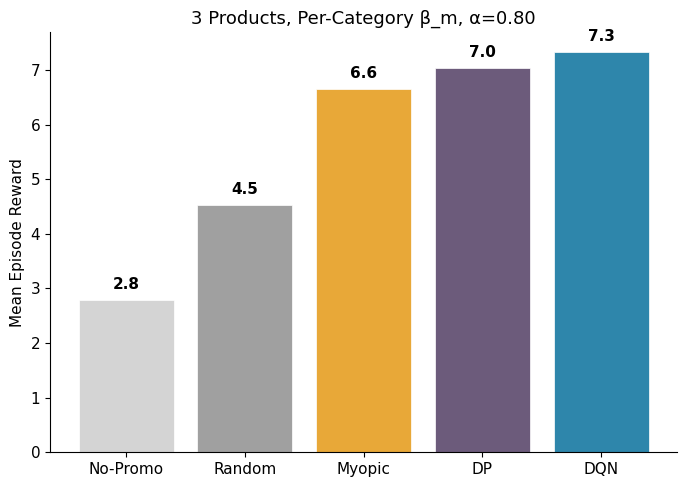

In [73]:
# ── Experiment 1 figure ──
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

COLORS = {"DQN": "#2E86AB", "DP": "#6C5B7B", "Random": "#A0A0A0", "Myopic": "#E8A838", "No-Promo": "#D4D4D4"}

r = exp1_result
policies = ["No-Promo", "Random", "Myopic"]
values = [r["no_promo"], r["random"], r["myopic"]]
if r["dp"] is not None:
    policies.append("DP")
    values.append(r["dp"])
policies.append("DQN")
values.append(r["dqn"])

colors = [COLORS[p] for p in policies]
bars = ax.bar(policies, values, color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(values),
            f"{val:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title(f"3 Products, Per-Category β_m, α=0.80", fontsize=13)
ax.set_ylabel("Mean Episode Reward")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [141]:
# ── Exp 1: Enriched comparison table (2000 episodes, for article) ──
env_eval = build_env(category_products_1, 1, decouple_memory_init=False)
from discount_engine.rl.rollout import run_rollout as _rollout

# Myopic action
expected_rev = (
    1 / (1 + np.exp(-(env_eval._beta_0 + env_eval.beta_p * env_eval._raw_deal_signal)))
) * env_eval._prices
myopic_action = int(expected_rev.argmax()) + 1

# Reload DQN (best checkpoint)
agent_exp1, _ = train_or_load(
    build_env(category_products_1, 1, decouple_memory_init=True, init_memory_frac=0.3),
    label="percat_3prod_a0.80_15k",
    n_episodes=10_000, eval_interval=500, eps_decay_steps=50_000, hidden=64,
)
dqn_fn = lambda obs: agent_exp1.select_action(obs, greedy=True)

# Round-robin FM→IC
def make_rr_fn():
    idx = [0]
    def fn(obs):
        a = [1, 2][idx[0] % 2]
        idx[0] += 1
        return a
    return fn

# Blind DQN-mix (will be set after first pass to get DQN action dist)
# First pass: get DQN action distribution from 500 episodes
stats_dqn_pre = _rollout(env_eval, n_episodes=500, policy=dqn_fn, seed=99)
counts_pre = np.bincount(stats_dqn_pre["actions"], minlength=env_eval.N + 1).astype(float)
dqn_probs = counts_pre / counts_pre.sum()
print(f"DQN action probs for blind mix: {dqn_probs}")

def make_mix_fn(seed):
    rng = np.random.RandomState(seed)
    def fn(obs):
        return int(rng.choice(len(dqn_probs), p=dqn_probs))
    return fn

# Category short names for action labels
action_labels = ["None"]
for j in range(env_eval.N):
    short = env_eval.params[env_eval.products[j]]["category"].split("/")[0].split(" - ")[0]
    action_labels.append(short[:2].upper())

eval_seeds = [99, 200, 300, 400]

policies = [
    ("No-Promo",      lambda s: "no_promo"),
    ("Random",        lambda s: "random"),
    ("Greedy-Myopic", lambda s: myopic_action),
    ("Blind DQN-mix", lambda s: make_mix_fn(s)),
    ("DQN",           lambda s: dqn_fn),
    ("DP",            lambda s: dp_policy_fn),
    ("Optimal RR (FM→IC)", lambda s: make_rr_fn()),
]

header_actions = "  ".join(f"{l:>4s}" for l in action_labels)
print(f"\n{'Policy':<22s}  {'Reward':>14s}  {'Ep Len':>6s}  {'Purch/Step':>10s}  {header_actions}")
print("-" * 90)

exp1_results = {}
for name, make_policy in policies:
    all_rewards, all_lengths, all_purch, all_actions = [], [], [], []
    for s in eval_seeds:
        policy = make_policy(s)
        stats = _rollout(env_eval, n_episodes=500, policy=policy, seed=s)
        all_rewards.append(stats["rewards"])
        all_lengths.append(stats["lengths"])
        all_purch.append(stats["purchases_per_step"])
        all_actions.append(stats["actions"])
    combined_r = np.concatenate(all_rewards)
    combined_l = np.concatenate(all_lengths)
    combined_p = np.concatenate(all_purch)
    combined_a = np.concatenate(all_actions)
    
    mean_r = combined_r.mean()
    se_r = combined_r.std() / np.sqrt(len(combined_r))
    mean_len = combined_l.mean()
    purch_rate = combined_p.mean()
    
    counts = np.bincount(combined_a, minlength=env_eval.N + 1).astype(float)
    pcts = counts / counts.sum() * 100
    act_str = "  ".join(f"{p:>4.0f}%" for p in pcts)
    
    r_str = f"{mean_r:.2f}±{se_r:.2f}"
    print(f"{name:<22s}  {r_str:>14s}  {mean_len:>6.1f}  {purch_rate:>10.2f}  {act_str}")
    
    exp1_results[name] = {"mean": mean_r, "se": se_r, "ep_len": mean_len, "purch_step": purch_rate}

  Loaded BEST model ← percat_3prod_a0.80_15k_961b7ccbcfee.pt
DQN action probs for blind mix: [0.07295416 0.50827934 0.18382529 0.2349412 ]

Policy                          Reward  Ep Len  Purch/Step  None    FL    IC    FR
------------------------------------------------------------------------------------------
No-Promo                     2.83±0.13    13.0        0.10   100%     0%     0%     0%
Random                       4.52±0.17    14.8        0.18    25%    25%    25%    25%
Greedy-Myopic                6.96±0.21    17.5        0.27     0%   100%     0%     0%
Blind DQN-mix                6.70±0.23    17.0        0.26     7%    51%    18%    24%
DQN                          7.30±0.23    17.5        0.27     7%    50%    19%    24%
DP                           7.48±0.24    17.8        0.28     0%    95%     5%     0%
Optimal RR (FM→IC)           7.97±0.27    18.6        0.28     0%    50%    50%     0%


In [137]:
# ── Exp 1: Round-robin & DQN-mix baselines (2000 episodes, full stats) ──

env_1_rr = build_env(category_products_1, 1, decouple_memory_init=False)

# DQN's action distribution from enriched table: None 7%, FM 51%, IC 18%, FP 23%
dqn_action_probs_1 = np.array([0.07, 0.51, 0.18, 0.23])
dqn_action_probs_1 = dqn_action_probs_1 / dqn_action_probs_1.sum()  # ensure sum=1

# Round-robin configs to test
# Actions: 0=None, 1=FM, 2=IC, 3=FP
rr_configs_1 = {
    "RR: FM + IC": [1, 2],
    "RR: FM + FP": [1, 3],
    "RR: FM + IC + FP": [1, 2, 3],
}

eval_seeds = [99, 200, 300, 400]

print("── Exp 1: Full Stats for Article Table (2000 episodes) ──\n")
print(f"{'Policy':<22s} {'Reward':>14s} {'Ep Len':>8s} {'P/Step':>8s}")
print("-" * 54)

# Round-robin
best_rr_name, best_rr_mean, best_rr_se = None, -np.inf, 0
for name, action_seq in rr_configs_1.items():
    all_rewards, all_lengths, all_purch = [], [], []
    for s in eval_seeds:
        def make_rr_policy(seq):
            idx = [0]
            def fn(obs):
                a = seq[idx[0] % len(seq)]
                idx[0] += 1
                return a
            return fn
        rr_fn = make_rr_policy(action_seq)
        stats = _rollout(env_1_rr, n_episodes=500, policy=rr_fn, seed=s)
        all_rewards.append(stats["rewards"])
        all_lengths.append(stats["lengths"])
        all_purch.append(stats["purchases_per_step"])
    combined_r = np.concatenate(all_rewards)
    combined_l = np.concatenate(all_lengths)
    combined_p = np.concatenate(all_purch)
    mean_r = combined_r.mean()
    se_r = combined_r.std() / np.sqrt(len(combined_r))
    print(f"  {name:<20s} {mean_r:>6.2f} ± {se_r:.2f} {combined_l.mean():>8.1f} {combined_p.mean():>8.2f}")
    if mean_r > best_rr_mean:
        best_rr_name, best_rr_mean, best_rr_se = name, mean_r, se_r

# Random DQN-mix
all_rewards, all_lengths, all_purch = [], [], []
for s in eval_seeds:
    mix_rng = np.random.RandomState(s)
    def random_dqn_mix_1(obs):
        return int(mix_rng.choice(4, p=dqn_action_probs_1))
    stats = _rollout(env_1_rr, n_episodes=500, policy=random_dqn_mix_1, seed=s)
    all_rewards.append(stats["rewards"])
    all_lengths.append(stats["lengths"])
    all_purch.append(stats["purchases_per_step"])
combined_r = np.concatenate(all_rewards)
combined_l = np.concatenate(all_lengths)
combined_p = np.concatenate(all_purch)
mix_mean = combined_r.mean()
mix_se = combined_r.std() / np.sqrt(len(combined_r))
print(f"  {'Random DQN-mix':<20s} {mix_mean:>6.2f} ± {mix_se:.2f} {combined_l.mean():>8.1f} {combined_p.mean():>8.2f}")

# DQN reference (from 2000-ep stability: 6.96 ± 0.46)
dqn_reward_1 = 6.96
print(f"\n  DQN vs best RR ({best_rr_name}): {(dqn_reward_1/best_rr_mean - 1)*100:+.1f}%")
print(f"  DQN vs random DQN-mix: {(dqn_reward_1/mix_mean - 1)*100:+.1f}%")

# Save for chart
exp1_rr_best_mean, exp1_rr_best_se = best_rr_mean, best_rr_se
exp1_mix_mean, exp1_mix_se = mix_mean, mix_se

── Exp 1: Full Stats for Article Table (2000 episodes) ──

Policy                         Reward   Ep Len   P/Step
------------------------------------------------------
  RR: FM + IC            7.97 ± 0.27     18.6     0.28
  RR: FM + FP            7.23 ± 0.23     17.7     0.27
  RR: FM + IC + FP       6.06 ± 0.21     16.5     0.23
  Random DQN-mix         6.75 ± 0.23     17.3     0.26

  DQN vs best RR (RR: FM + IC): -12.7%
  DQN vs random DQN-mix: +3.1%


In [138]:
# ── Exp 1: Q-value gap analysis ──
# Sample states from rollouts and compute Q(s,a) for all actions.
# Shows how confident the DQN is in its greedy action vs alternatives.

env_q = build_env(category_products_1, 1, decouple_memory_init=False)
action_labels_q = ["None"]
for j in range(env_q.N):
    short = env_q.params[env_q.products[j]]["category"].split("/")[0].split(" - ")[0]
    action_labels_q.append(short[:2].upper())

# Collect states from evaluation rollouts
states_collected = []
for ep in range(100):
    obs, _ = env_q.reset(seed=200 + ep)
    done = False
    while not done:
        states_collected.append(obs.copy())
        action = agent_exp1.select_action(obs, greedy=True)
        obs, _, terminated, truncated, _ = env_q.step(action)
        done = terminated or truncated

states_arr = np.array(states_collected)
print(f"Collected {len(states_arr)} states from 100 episodes\n")

# Compute Q-values for all states
q_all = np.array([agent_exp1.get_q_values(s) for s in states_arr])

# Summary statistics
greedy_actions = q_all.argmax(axis=1)
q_greedy = q_all.max(axis=1)
q_second = np.sort(q_all, axis=1)[:, -2]
q_gap = q_greedy - q_second  # gap between best and second-best action

print("Q-value summary (across all sampled states):")
print(f"  Mean Q by action: {', '.join(f'{action_labels_q[a]}={q_all[:, a].mean():.3f}' for a in range(q_all.shape[1]))}")
print(f"  Greedy action distribution: {', '.join(f'{action_labels_q[a]}={((greedy_actions == a).sum() / len(greedy_actions) * 100):.1f}%' for a in range(q_all.shape[1]))}")
print(f"\nQ-gap (greedy − second-best):")
print(f"  Mean: {q_gap.mean():.3f}")
print(f"  Median: {np.median(q_gap):.3f}")
print(f"  Std: {q_gap.std():.3f}")
print(f"  Min: {q_gap.min():.3f}, Max: {q_gap.max():.3f}")
print(f"  % of states with gap < 0.1: {(q_gap < 0.1).mean() * 100:.1f}%")
print(f"  % of states with gap < 0.5: {(q_gap < 0.5).mean() * 100:.1f}%")

# Show Q-values at a few representative states
print("\n── Representative states ──")
# High churn, low churn, mid churn
churn_vals = states_arr[:, 0]
for label, idx in [
    ("Low churn",  np.argmin(churn_vals)),
    ("Med churn",  np.argsort(churn_vals)[len(churn_vals) // 2]),
    ("High churn", np.argmax(churn_vals)),
]:
    s = states_arr[idx]
    qv = q_all[idx]
    best = qv.argmax()
    gap = qv[best] - np.sort(qv)[-2]
    q_str = ", ".join(f"{action_labels_q[a]}={qv[a]:.3f}" for a in range(len(qv)))
    print(f"  {label} (c={s[0]:.3f}): [{q_str}]  → greedy={action_labels_q[best]}, gap={gap:.3f}")

Collected 1410 states from 100 episodes

Q-value summary (across all sampled states):
  Mean Q by action: None=0.748, FL=0.776, IC=0.761, FR=0.764
  Greedy action distribution: None=6.9%, FL=50.4%, IC=19.7%, FR=23.0%

Q-gap (greedy − second-best):
  Mean: 0.011
  Median: 0.006
  Std: 0.014
  Min: 0.000, Max: 0.127
  % of states with gap < 0.1: 99.7%
  % of states with gap < 0.5: 100.0%

── Representative states ──
  Low churn (c=0.015): [None=0.659, FL=0.703, IC=0.634, FR=0.655]  → greedy=FL, gap=0.044
  Med churn (c=0.084): [None=0.786, FL=0.823, IC=0.804, FR=0.823]  → greedy=FL, gap=0.001
  High churn (c=0.160): [None=0.048, FL=0.059, IC=0.060, FR=0.055]  → greedy=IC, gap=0.001


In [ ]:
# ── Greedy policy heatmap helper ──
# Per-product panel: churn (x) vs that product's memory (y), colored by modal action.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from scipy.stats import mode as scipy_mode

HEATMAP_COLORS = {
    "No-promo": "#D4D4D4",              # gray
    "FLUID MILK": "#2E86AB",            # blue
    "FLUID MILK PRODUCTS": "#2E86AB",   # blue (alias)
    "ICE CREAM": "#6C5B7B",             # purple
    "FROZEN PIZZA": "#C97B3D",          # brown-ish
    "CANDY": "#E87B9A",                 # pink
    "SOFT DRINKS": "#8B5E3C",           # brown
    "BAG SNACKS": "#E8D838",            # yellow
}


def plot_policy_heatmaps(obs_action_pairs, title, n_products, action_map,
                         n_bins=20, figsize=None, shared_ylim=False, min_obs=3):
    """Per-product heatmap: churn (x) vs product memory (y), colored by modal action.

    obs_action_pairs: list of (obs_array, action) tuples
    action_map: {action_idx: short_name}
    shared_ylim: if True, all panels share the same y-axis range
    min_obs: minimum observations per bin to show (default 3)
    """
    N = n_products
    states = np.array([o for o, _ in obs_action_pairs])
    actions = np.array([a for _, a in obs_action_pairs])
    churn_vals = states[:, 0]

    # Build category-level mapping for multi-product envs
    categories = [action_map.get(a, "") for a in range(1, N + 1)]
    unique_cats = list(dict.fromkeys(categories))
    cat_labels = ["No-promo"] + unique_cats
    cat_colors = [HEATMAP_COLORS.get(l, f"C{i}") for i, l in enumerate(cat_labels)]
    cmap = ListedColormap(cat_colors)
    bounds = np.arange(-0.5, len(cat_labels) + 0.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    action_to_cat_idx = np.zeros(N + 1, dtype=int)
    for a in range(1, N + 1):
        name = action_map.get(a, "")
        if name in unique_cats:
            action_to_cat_idx[a] = unique_cats.index(name) + 1
    action_cats = action_to_cat_idx[actions]

    # Compute global memory range if shared_ylim
    if shared_ylim:
        all_mems = states[:, 1:1+N]
        global_mem_min = all_mems.min()
        global_mem_max = all_mems.max()

    # One panel per unique category
    n_panels = len(unique_cats)
    ncols = min(n_panels, 3)
    nrows = (n_panels + ncols - 1) // ncols
    if figsize is None:
        figsize = (5 * ncols, 4.5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    for panel_idx, cat_name in enumerate(unique_cats):
        ax = axes[panel_idx // ncols, panel_idx % ncols]
        cat_action_idx = unique_cats.index(cat_name) + 1
        prod_indices = [a - 1 for a in range(1, N + 1) if action_to_cat_idx[a] == cat_action_idx]
        if not prod_indices:
            ax.set_visible(False)
            continue

        cat_mem = states[:, [1 + i for i in prod_indices]].mean(axis=1)

        churn_bins = np.linspace(churn_vals.min(), churn_vals.max() + 1e-6, n_bins + 1)
        if shared_ylim:
            mem_bins = np.linspace(global_mem_min, global_mem_max + 1e-6, n_bins + 1)
        else:
            mem_bins = np.linspace(cat_mem.min(), cat_mem.max() + 1e-6, n_bins + 1)
        churn_bin_idx = np.digitize(churn_vals, churn_bins) - 1
        mem_bin_idx = np.digitize(cat_mem, mem_bins) - 1

        grid_mode = np.full((n_bins, n_bins), np.nan)
        for i in range(n_bins):
            for j in range(n_bins):
                mask = (churn_bin_idx == i) & (mem_bin_idx == j)
                if mask.sum() >= min_obs:
                    grid_mode[j, i] = scipy_mode(action_cats[mask], keepdims=False).mode

        masked_grid = np.ma.masked_invalid(grid_mode)
        ax.imshow(masked_grid, origin="lower", aspect="auto", cmap=cmap, norm=norm,
                  extent=[churn_bins[0], churn_bins[-1], mem_bins[0], mem_bins[-1]])
        ax.set_xlabel("Churn Propensity")
        ax.set_ylabel(f"{cat_name} Memory ($)")
        ax.set_title(cat_name, fontsize=12, fontweight="bold")

    for idx in range(n_panels, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    legend_patches = [Patch(facecolor=c, edgecolor="black", label=l)
                      for l, c in zip(cat_labels, cat_colors)]
    fig.legend(handles=legend_patches, loc="lower center", ncol=len(cat_labels),
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    return fig

print("Policy heatmap helper ready.")

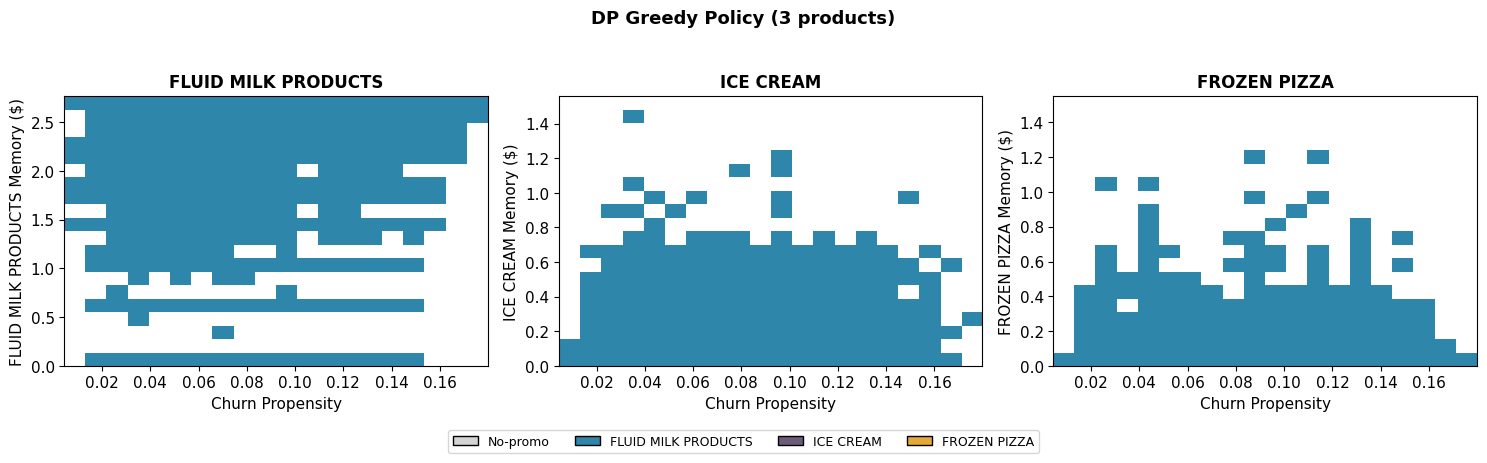

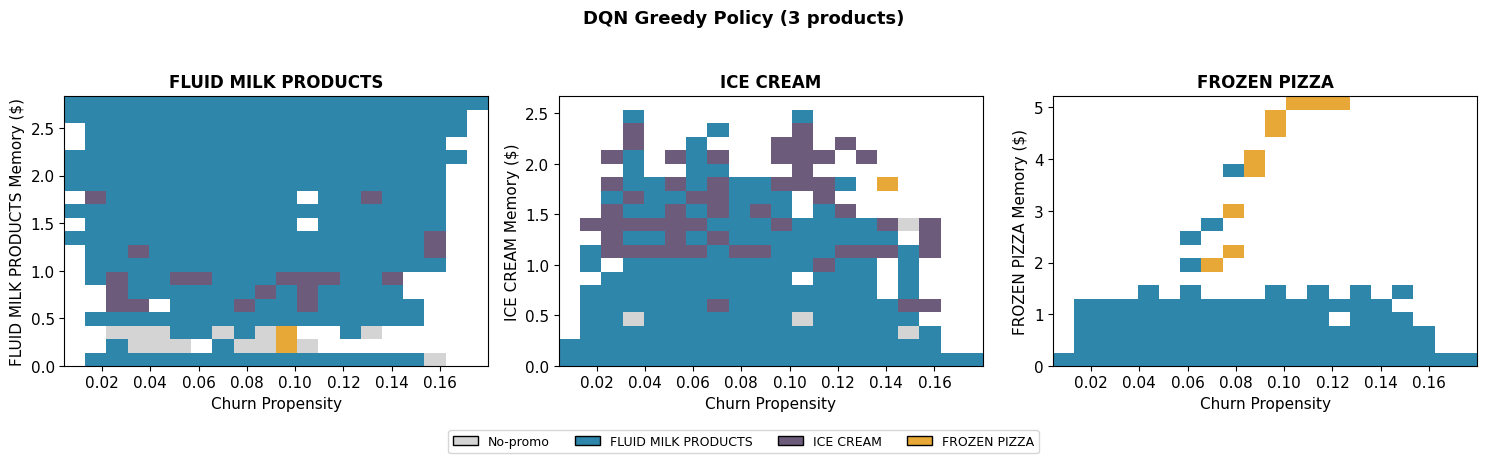

In [15]:
# ── Exp 1: Greedy policy heatmaps (DP + DQN) ──
exp1_action_map = {0: "No-promo"}
for i, cat in enumerate(DP_CATEGORIES):
    exp1_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

if exp1_result["dp_obs_actions"]:
    fig = plot_policy_heatmaps(
        exp1_result["dp_obs_actions"],
        "DP Greedy Policy (3 products)",
        n_products=3, action_map=exp1_action_map,
    )
    plt.show()

fig = plot_policy_heatmaps(
    exp1_result["dqn_obs_actions"],
    "DQN Greedy Policy (3 products)",
    n_products=3, action_map=exp1_action_map,
)
plt.show()

## Experiment 2: 5 Products per Category (RL-Only Scale)

15 products, 16 actions, 31-dim state. DP cannot solve this (~1.4T states).
This is where RL must demonstrate value: cross-category product selection, churn-dependent behavior, and no-promo rests — in a setting that tabular methods cannot reach.

In [16]:
# ── Experiment 2: 5 products per category, α=0.80 ──
exp2_result = run_experiment(
    env_fn=lambda **kw: build_env(category_products_5, 5, **kw),
    label="pooled_15prod_a0.80",
    n_episodes=30_000, eps_decay_steps=100_000, hidden=128,
)


  pooled_15prod_a0.80

  ── Baselines ──
  No-promo:       23.99
  Random:         24.85
  Greedy-myopic:  31.47  (always FLUID MILK PRODUCTS)


Training pooled_15prod_a0.80:   0%|          | 0/30000 [00:00<?, ?it/s]

  [ep   500] eval=29.79  mean_q=0.93  max_q=1.70  loss=0.0080  eps=0.891
  [ep  1000] eval=27.58  mean_q=1.86  max_q=3.38  loss=0.0173  eps=0.772
  [ep  1500] eval=35.44  mean_q=3.02  max_q=5.52  loss=0.0239  eps=0.654
  [ep  2000] eval=32.76  mean_q=3.86  max_q=7.19  loss=0.0225  eps=0.536
  [ep  2500] eval=30.23  mean_q=4.46  max_q=8.11  loss=0.0208  eps=0.408
  [ep  3000] eval=32.98  mean_q=4.98  max_q=8.96  loss=0.0244  eps=0.294
  [ep  3500] eval=31.53  mean_q=5.36  max_q=9.45  loss=0.0276  eps=0.164
  [ep  4000] eval=31.24  mean_q=5.48  max_q=10.12  loss=0.0294  eps=0.054
  [ep  4500] eval=29.18  mean_q=5.76  max_q=10.88  loss=0.0310  eps=0.050
  [ep  5000] eval=33.25  mean_q=6.19  max_q=11.64  loss=0.0322  eps=0.050
  [ep  5500] eval=34.18  mean_q=6.22  max_q=12.39  loss=0.0348  eps=0.050
  [ep  6000] eval=26.21  mean_q=6.31  max_q=13.20  loss=0.0348  eps=0.050
  [ep  6500] eval=36.24  mean_q=6.64  max_q=13.58  loss=0.0372  eps=0.050
  [ep  7000] eval=30.31  mean_q=6.60  max_q=1

In [20]:
# ── Exp 2b: Same but train WITHOUT decouple_memory_init ──
# Tests whether the train→holdout gap is from init distribution mismatch.
exp2b_result = run_experiment(
    env_fn=lambda **kw: build_env(category_products_5, 5, decouple_memory_init=False),
    label="pooled_15prod_nodecoup",
    n_episodes=10_000, eps_decay_steps=100_000, hidden=128,
)


  pooled_15prod_nodecoup

  ── Baselines ──
  No-promo:       23.99
  Random:         26.09
  Greedy-myopic:  31.47  (always FLUID MILK PRODUCTS)


Training pooled_15prod_nodecoup:   0%|          | 0/10000 [00:00<?, ?it/s]

  [ep   500] eval=35.13  mean_q=1.04  max_q=1.75  loss=0.0088  eps=0.886
  [ep  1000] eval=35.92  mean_q=2.29  max_q=3.81  loss=0.0190  eps=0.764
  [ep  1500] eval=36.85  mean_q=3.44  max_q=6.18  loss=0.0252  eps=0.644
  [ep  2000] eval=27.35  mean_q=4.28  max_q=8.20  loss=0.0225  eps=0.525
  [ep  2500] eval=28.08  mean_q=5.07  max_q=8.81  loss=0.0226  eps=0.400
  [ep  3000] eval=28.53  mean_q=5.61  max_q=9.33  loss=0.0262  eps=0.285
  [ep  3500] eval=35.42  mean_q=6.12  max_q=10.08  loss=0.0307  eps=0.156
  [ep  4000] eval=30.42  mean_q=6.56  max_q=10.97  loss=0.0330  eps=0.050
  [ep  4500] eval=35.21  mean_q=6.75  max_q=11.62  loss=0.0357  eps=0.050
  [ep  5000] eval=33.95  mean_q=6.70  max_q=11.94  loss=0.0370  eps=0.050
  [ep  5500] eval=32.04  mean_q=7.00  max_q=12.09  loss=0.0387  eps=0.050
  [ep  6000] eval=36.30  mean_q=7.07  max_q=12.85  loss=0.0398  eps=0.050
  [ep  6500] eval=29.39  mean_q=7.10  max_q=13.02  loss=0.0405  eps=0.050
  [ep  7000] eval=31.58  mean_q=7.23  max_q=

In [17]:
# ── Experiment 2 summary ──
print("="*70)
print("  Experiment 2: 5 Products per Category (RL-Only Scale)")
print("="*70)
r = exp2_result
print(f"\n  DQN:            {r['dqn']:.2f} ± {r['dqn_se']:.2f}")
print(f"  Random:         {r['random']:.2f}")
print(f"  Greedy-myopic:  {r['myopic']:.2f}")
print(f"  No-promo:       {r['no_promo']:.2f}")
print(f"\n  DQN vs Random:  {(r['dqn']/r['random'] - 1)*100:+.1f}%")
print(f"  DQN vs Myopic:  {(r['dqn']/r['myopic'] - 1)*100:+.1f}%")
print(f"  DQN vs No-Pro:  {(r['dqn']/r['no_promo'] - 1)*100:+.1f}%")
print(f"\n  Category allocation:")
for name, pct in r['cat_pct'].items():
    print(f"    {name}: {pct:.1f}%")
print(f"\n  Entropy: {r['entropy']:.2f}, Repeat rate: {r['repeat_rate']:.1%}")
print(f"  Rotation Δ: {r['rotation_delta']:+.1%}")

  Experiment 2: 5 Products per Category (RL-Only Scale)

  DQN:            26.48 ± 1.95
  Random:         24.85
  Greedy-myopic:  31.47
  No-promo:       23.99

  DQN vs Random:  +6.6%
  DQN vs Myopic:  -15.8%
  DQN vs No-Pro:  +10.4%

  Category allocation:
    No-promo: 7.7%
    FLUID MILK PRODUCTS: 41.6%
    ICE CREAM: 19.6%
    FROZEN PIZZA: 31.2%

  Entropy: 1.38, Repeat rate: 39.3%
  Rotation Δ: -29.3%


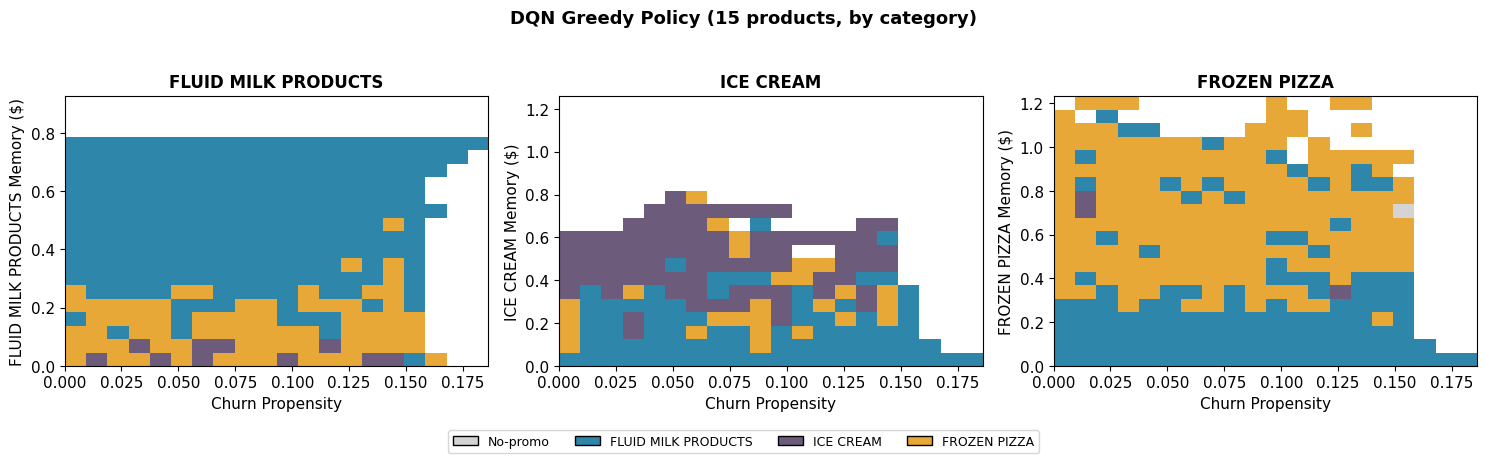

In [18]:
# ── Exp 2: Greedy policy heatmap (DQN, 15 products → aggregate by category) ──
env_exp2 = build_env(category_products_5, 5, decouple_memory_init=False)

# Map product-level actions to category-level
exp2_cat_obs_actions = []
for obs, action in exp2_result["dqn_obs_actions"]:
    if action == 0:
        cat_action = 0
    else:
        prod_cat = env_exp2.params[env_exp2.products[action - 1]]["category"]
        cat_action = DP_CATEGORIES.index(prod_cat) + 1
    # Average product memories within each category
    cat_mems = []
    for cat in DP_CATEGORIES:
        prod_indices = [j for j in range(env_exp2.N)
                       if env_exp2.params[env_exp2.products[j]]["category"] == cat]
        cat_mems.append(obs[[1 + j for j in prod_indices]].mean())
    fake_obs = np.array([obs[0]] + cat_mems + [0.0, 0.0, 0.0])
    exp2_cat_obs_actions.append((fake_obs, cat_action))

exp2_action_map = {0: "No-promo"}
for i, cat in enumerate(DP_CATEGORIES):
    exp2_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

fig = plot_policy_heatmaps(
    exp2_cat_obs_actions,
    "DQN Greedy Policy (15 products, by category)",
    n_products=3, action_map=exp2_action_map,
)
plt.show()

## Experiment 3: 6 Categories × 1 Product (DP-Intractable, Strong Fatigue)

DP caps at 5 categories. With 6 categories (7 actions, 13-dim state), DP is intractable but DQN's action space is still manageable. Each category uses a single high-volume product with per-category calibration at α=0.80.

**Category selection:** Top 6 categories by calibrated β_m from NB07, spanning a range of fatigue strengths (0.27–1.15). This ensures fatigue dynamics actually matter for the optimal policy.

In [32]:
# ── Experiment 3: 6 categories, 1 product each ──
# Reuse Exp 1's FM/IC/FP products (strong calibration), add 3 new categories.

EXP3_CATEGORIES = [
    "FLUID MILK PRODUCTS",       # from Exp 1
    "ICE CREAM/MILK/SHERBTS",    # from Exp 1
    "FROZEN PIZZA",              # from Exp 1
    "CANDY - PACKAGED",          # new — highest β_m in NB07
    "SOFT DRINKS",               # new — strong fatigue in NB07
    "BAG SNACKS",                # new — moderate fatigue
]

exp3_products = {
    "FLUID MILK PRODUCTS": [995242],       # Exp 1 product (β_m=0.94)
    "ICE CREAM/MILK/SHERBTS": [854042],    # Exp 1 product (β_m=0.82)
    "FROZEN PIZZA": [907631],              # Exp 1 product (β_m=0.41)
    "CANDY - PACKAGED": [9337581],         # top volume, NB07 tested
    "SOFT DRINKS": [844165],               # good volume + high discount activity
    "BAG SNACKS": [5568378],               # top volume
}

# Show selected products
print("── Exp 3: 6 Categories × 1 Product ──")
for cat in EXP3_CATEGORIES:
    pid = exp3_products[cat][0]
    pid_data = merged[merged["product_id"] == pid]
    price = pid_data["sales_value"].median()
    disc = pid_data["discount_rate"].median()
    n = len(pid_data)
    short = cat.split("/")[0].split(" - ")[0]
    print(f"  {short:<20s} pid={pid}  ${price:.2f}  disc={disc:.3f}  n={n:,}")

── Exp 3: 6 Categories × 1 Product ──
  FLUID MILK PRODUCTS  pid=995242  $1.89  disc=0.690  n=12,542
  ICE CREAM            pid=854042  $2.00  disc=0.495  n=299
  FROZEN PIZZA         pid=907631  $3.49  disc=0.086  n=857
  CANDY                pid=9337581  $1.00  disc=0.390  n=917
  SOFT DRINKS          pid=844165  $1.34  disc=0.590  n=3,025
  BAG SNACKS           pid=5568378  $2.19  disc=0.375  n=2,692


In [33]:
# ── Exp 3: Per-category calibration ──
exp3_calibrations = {}
cache_path = CACHE_DIR / "calibration_exp3_6cat.pkl"

if cache_path.exists():
    with open(cache_path, "rb") as f:
        exp3_calibrations = pickle.load(f)
    print("Loaded cached Exp 3 calibration")
else:
    t0 = time.perf_counter()
    for cat in EXP3_CATEGORIES:
        pids = exp3_products[cat]
        result = calibrate_category(cat, pids, alpha_candidates=[0.80])
        exp3_calibrations[cat] = result
        short = cat.split("/")[0].split(" - ")[0]
        print(f"  {short:<20s} β_m={result['beta_m']:.4f}  β_p={result['beta_p']:.4f}  "
              f"β_l={result['beta_l']:.4f}  β_0={result['intercepts'][0]:.3f}")
    with open(cache_path, "wb") as f:
        pickle.dump(exp3_calibrations, f)
    print(f"  Done in {time.perf_counter()-t0:.1f}s")

print("\n── Exp 3 Calibration Summary ──")
for cat in EXP3_CATEGORIES:
    r = exp3_calibrations[cat]
    short = cat.split("/")[0].split(" - ")[0]
    print(f"  {short:<20s} β_m={r['beta_m']:.4f}  β_p={r['beta_p']:.4f}  β_l={r['beta_l']:.4f}")

  FLUID MILK PRODUCTS  β_m=0.9387  β_p=5.0152  β_l=0.0582  β_0=-1.184
  ICE CREAM            β_m=0.8205  β_p=2.7108  β_l=0.0524  β_0=-3.725
  FROZEN PIZZA         β_m=0.4083  β_p=0.9553  β_l=0.0679  β_0=-2.117
  CANDY                β_m=2.1934  β_p=8.7394  β_l=0.0482  β_0=-2.886
  SOFT DRINKS          β_m=0.6126  β_p=3.5411  β_l=0.0633  β_0=-1.756
  BAG SNACKS           β_m=0.2104  β_p=1.4633  β_l=0.0474  β_0=-2.269
  Done in 4.5s

── Exp 3 Calibration Summary ──
  FLUID MILK PRODUCTS  β_m=0.9387  β_p=5.0152  β_l=0.0582
  ICE CREAM            β_m=0.8205  β_p=2.7108  β_l=0.0524
  FROZEN PIZZA         β_m=0.4083  β_p=0.9553  β_l=0.0679
  CANDY                β_m=2.1934  β_p=8.7394  β_l=0.0482
  SOFT DRINKS          β_m=0.6126  β_p=3.5411  β_l=0.0633
  BAG SNACKS           β_m=0.2104  β_p=1.4633  β_l=0.0474


In [34]:
# ── Exp 3: Build env + run ──

def build_exp3_env(decouple_memory_init=True, init_memory_frac=0.3):
    """Create 6-category env with per-category calibrated params."""
    cal = exp3_calibrations
    product_ids, beta_0_list, beta_m_list, beta_p_list, beta_l_list = [], [], [], [], []
    categories, prices, deal_signals = [], [], []

    for cat in EXP3_CATEGORIES:
        r = cal[cat]
        pid = exp3_products[cat][0]
        product_ids.append(pid)
        beta_0_list.append(r["intercepts"][0])
        beta_m_list.append(r["beta_m"])
        beta_p_list.append(r["beta_p"])
        beta_l_list.append(r["beta_l"])
        categories.append(cat)
        pid_txn = merged[merged["product_id"] == pid]
        price = float(pid_txn["sales_value"].median())
        prices.append(price)
        deal_signals.append(price * DELTA)

    pp = {}
    for i, pid in enumerate(product_ids):
        pp[pid] = {
            "beta_0": beta_0_list[i],
            "raw_deal_signal": deal_signals[i],
            "price": prices[i],
            "category": categories[i],
        }

    return DiscountEnv(
        product_params=pp, product_order=product_ids,
        beta_p=np.array(beta_p_list), beta_l=np.array(beta_l_list),
        beta_m=np.array(beta_m_list), alpha=ALPHA,
        c0=V2_C0, eta=V2_ETA, churn_cost=0.0,
        decouple_memory_init=decouple_memory_init,
        init_memory_frac=init_memory_frac,
    )

# Sanity check
env3 = build_exp3_env()
print(f"Exp 3: {env3.N} products, dim={env3.observation_space.shape[0]}, "
      f"actions={env3.action_space.n}")
for j in range(env3.N):
    pid = env3.products[j]
    p = env3.params[pid]
    bm = env3.beta_m[j]
    bp = env3.beta_p[j]
    short = p["category"].split("/")[0].split(" - ")[0]
    boost = bp * p["raw_deal_signal"]
    print(f"  [{j}] {short:<20s} ${p['price']:.2f}  deal=${p['raw_deal_signal']:.3f}  "
          f"β_m={bm:.3f}  β_p={bp:.3f}  boost={boost:.2f}")

# Run experiment
exp3_result = run_experiment(
    env_fn=lambda **kw: build_exp3_env(**kw),
    label="6cat_1prod_a0.80",
    n_episodes=10_000, eps_decay_steps=50_000, hidden=64,
)

Exp 3: 6 products, dim=13, actions=7
  [0] FLUID MILK PRODUCTS  $1.89  deal=$0.567  β_m=0.939  β_p=5.015  boost=2.84
  [1] ICE CREAM            $2.00  deal=$0.600  β_m=0.821  β_p=2.711  boost=1.63
  [2] FROZEN PIZZA         $3.49  deal=$1.047  β_m=0.408  β_p=0.955  boost=1.00
  [3] CANDY                $1.00  deal=$0.300  β_m=2.193  β_p=8.739  boost=2.62
  [4] SOFT DRINKS          $1.34  deal=$0.402  β_m=0.613  β_p=3.541  boost=1.42
  [5] BAG SNACKS           $2.19  deal=$0.657  β_m=0.210  β_p=1.463  boost=0.96

  6cat_1prod_a0.80

  ── Baselines ──
  No-promo:       4.32
  Random:         6.47
  Greedy-myopic:  9.45  (always FLUID MILK PRODUCTS)


Training 6cat_1prod_a0.80:   0%|          | 0/10000 [00:00<?, ?it/s]

  [ep   500] eval=6.17  mean_q=0.34  max_q=0.53  loss=0.0033  eps=0.852
  [ep  1000] eval=7.91  mean_q=0.53  max_q=0.93  loss=0.0047  eps=0.688
  [ep  1500] eval=8.05  mean_q=0.65  max_q=1.23  loss=0.0053  eps=0.525
  [ep  2000] eval=7.00  mean_q=0.74  max_q=1.53  loss=0.0053  eps=0.356
  [ep  2500] eval=7.32  mean_q=0.83  max_q=1.80  loss=0.0044  eps=0.196
  [ep  3000] eval=5.76  mean_q=0.83  max_q=1.96  loss=0.0036  eps=0.050
  [ep  3500] eval=9.13  mean_q=0.89  max_q=2.17  loss=0.0034  eps=0.050
  [ep  4000] eval=6.50  mean_q=0.92  max_q=2.34  loss=0.0038  eps=0.050
  [ep  4500] eval=8.22  mean_q=0.96  max_q=2.49  loss=0.0042  eps=0.050
  [ep  5000] eval=10.10  mean_q=1.00  max_q=2.66  loss=0.0044  eps=0.050
  [ep  5500] eval=7.18  mean_q=0.99  max_q=2.78  loss=0.0047  eps=0.050
  [ep  6000] eval=7.93  mean_q=1.02  max_q=2.97  loss=0.0048  eps=0.050
  [ep  6500] eval=8.10  mean_q=1.03  max_q=3.17  loss=0.0050  eps=0.050
  [ep  7000] eval=13.37  mean_q=1.06  max_q=3.32  loss=0.0051  

In [35]:
# ── Exp 3 summary ──
print("="*70)
print("  Experiment 3: 6 Categories × 1 Product (DP-Intractable)")
print("="*70)
r = exp3_result
print(f"\n  DQN:            {r['dqn']:.2f} ± {r['dqn_se']:.2f}")
print(f"  Random:         {r['random']:.2f}")
print(f"  Greedy-myopic:  {r['myopic']:.2f}")
print(f"  No-promo:       {r['no_promo']:.2f}")
print(f"\n  DQN vs Random:  {(r['dqn']/r['random'] - 1)*100:+.1f}%")
print(f"  DQN vs Myopic:  {(r['dqn']/r['myopic'] - 1)*100:+.1f}%")
print(f"\n  Category allocation:")
for name, pct in r['cat_pct'].items():
    print(f"    {name}: {pct:.1f}%")
print(f"\n  Repeat rate: {r['repeat_rate']:.1%}")
print(f"  Rotation Δ: {r['rotation_delta']:+.1%}")

  Experiment 3: 6 Categories × 1 Product (DP-Intractable)

  DQN:            10.58 ± 0.65
  Random:         6.47
  Greedy-myopic:  9.45
  No-promo:       4.32

  DQN vs Random:  +63.5%
  DQN vs Myopic:  +12.0%

  Category allocation:
    No-promo: 2.4%
    FLUID MILK PRODUCTS: 55.2%
    ICE CREAM: 1.9%
    FROZEN PIZZA: 6.3%
    CANDY: 5.2%
    SOFT DRINKS: 16.3%
    BAG SNACKS: 12.7%

  Repeat rate: 42.0%
  Rotation Δ: -18.9%


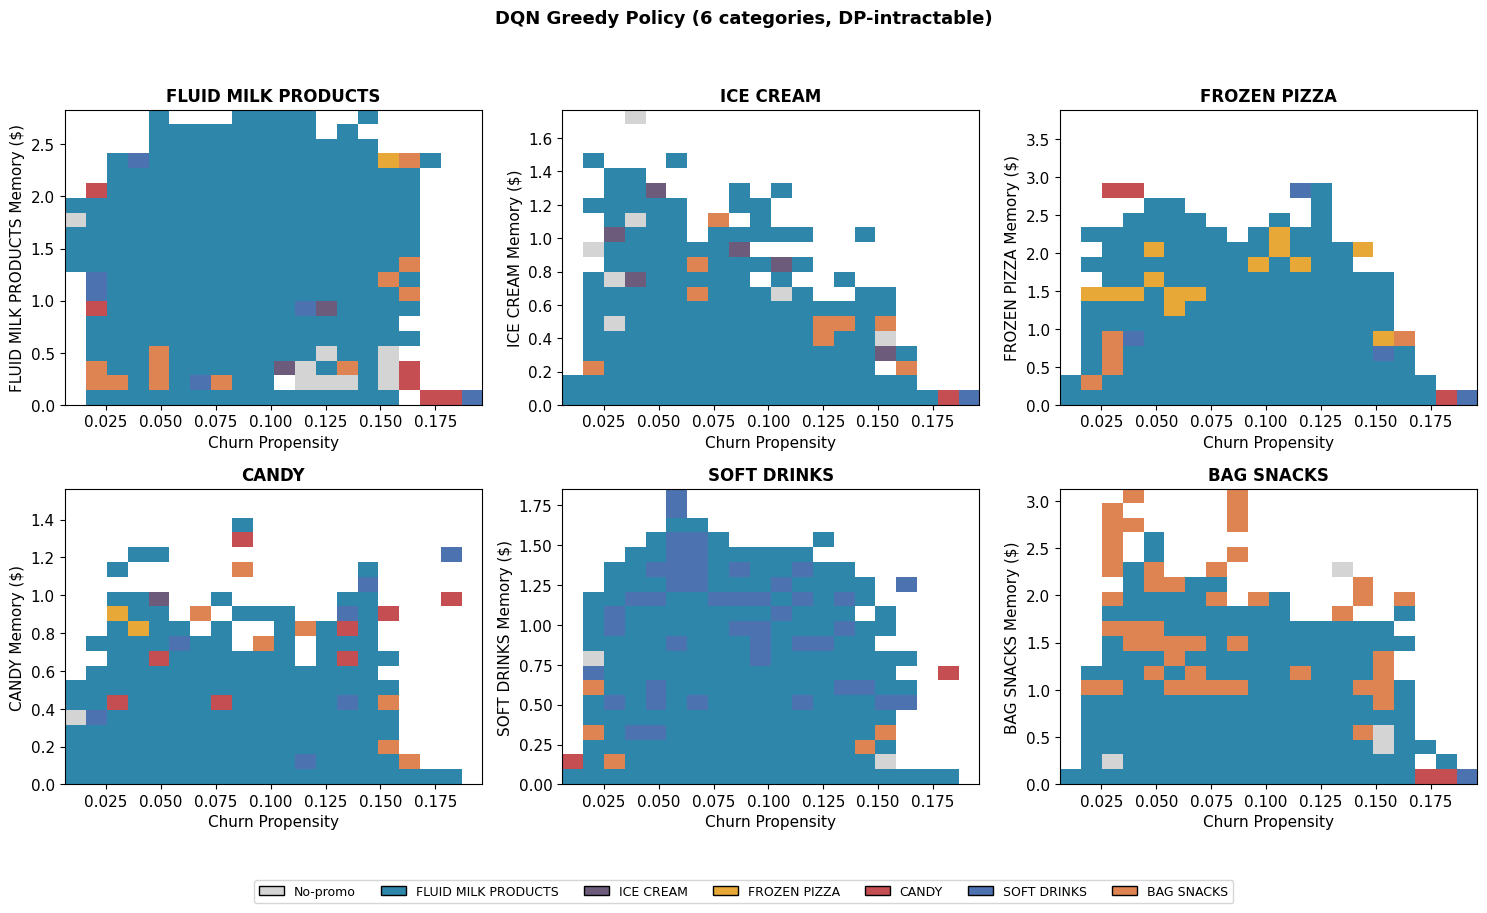

In [131]:
# ── Exp 3: Greedy policy heatmaps ──
# Update color map for the 6 categories
HEATMAP_COLORS.update({
    "CANDY": "#C44E52",
    "CANDY - PACKAGED": "#C44E52",
    "SOFT DRINKS": "#4C72B0",
    "LUNCHMEAT": "#55A868",
    "BAG SNACKS": "#DD8452",
})

exp3_action_map = {0: "No-promo"}
for i, cat in enumerate(EXP3_CATEGORIES):
    exp3_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

fig = plot_policy_heatmaps(
    exp3_result["dqn_obs_actions"],
    "DQN Greedy Policy (6 categories, DP-intractable)",
    n_products=6, action_map=exp3_action_map,
)
plt.show()

In [37]:
# ── Exp 3b: Same 6 categories, tighter churn init for longer episodes ──
# Init churn range [c0, 0.06] instead of [c0, 0.15] → longer episodes,
# more time for fatigue dynamics to matter.

def build_exp3b_env(decouple_memory_init=True, init_memory_frac=0.3):
    """Exp 3 env with tighter churn init for longer episodes."""
    cal = exp3_calibrations
    product_ids, beta_0_list, beta_m_list, beta_p_list, beta_l_list = [], [], [], [], []
    categories, prices, deal_signals = [], [], []

    for cat in EXP3_CATEGORIES:
        r = cal[cat]
        pid = exp3_products[cat][0]
        product_ids.append(pid)
        beta_0_list.append(r["intercepts"][0])
        beta_m_list.append(r["beta_m"])
        beta_p_list.append(r["beta_p"])
        beta_l_list.append(r["beta_l"])
        categories.append(cat)
        pid_txn = merged[merged["product_id"] == pid]
        price = float(pid_txn["sales_value"].median())
        prices.append(price)
        deal_signals.append(price * DELTA)

    pp = {}
    for i, pid in enumerate(product_ids):
        pp[pid] = {
            "beta_0": beta_0_list[i],
            "raw_deal_signal": deal_signals[i],
            "price": prices[i],
            "category": categories[i],
        }

    env = DiscountEnv(
        product_params=pp, product_order=product_ids,
        beta_p=np.array(beta_p_list), beta_l=np.array(beta_l_list),
        beta_m=np.array(beta_m_list), alpha=ALPHA,
        c0=V2_C0, eta=V2_ETA, churn_cost=0.0,
        decouple_memory_init=decouple_memory_init,
        init_memory_frac=init_memory_frac,
    )
    # Override the churn init range for longer episodes
    original_reset = env.reset
    def patched_reset(seed=None, options=None):
        result = original_reset(seed=seed, options=options)
        if env.randomize_init:
            churn, mem, rec = env._state
            churn = float(env.np_random.uniform(env.c0, 0.06))
            env._state = (churn, mem, rec)
            return env._get_state(), {}
        return result
    env.reset = patched_reset
    return env

# Quick check episode lengths
from discount_engine.rl.rollout import run_rollout as _rollout
_env = build_exp3b_env(decouple_memory_init=False)
_stats = _rollout(_env, n_episodes=500, policy='random', seed=42)
print(f"Exp 3b episode lengths: mean={_stats['lengths'].mean():.1f}  "
      f"median={np.median(_stats['lengths']):.0f}  "
      f"reward={_stats['rewards'].mean():.2f}")

exp3b_result = run_experiment(
    env_fn=lambda **kw: build_exp3b_env(**kw),
    label="6cat_1prod_tight_churn",
    n_episodes=10_000, eps_decay_steps=50_000, hidden=64,
)

Exp 3b episode lengths: mean=25.2  median=20  reward=10.43

  6cat_1prod_tight_churn

  ── Baselines ──
  No-promo:       7.16
  Random:         10.96
  Greedy-myopic:  14.52  (always FLUID MILK PRODUCTS)


Training 6cat_1prod_tight_churn:   0%|          | 0/10000 [00:00<?, ?it/s]

  [ep   500] eval=9.09  mean_q=0.48  max_q=1.07  loss=0.0037  eps=0.742
  [ep  1000] eval=11.10  mean_q=0.79  max_q=1.71  loss=0.0052  eps=0.505
  [ep  1500] eval=11.44  mean_q=1.00  max_q=2.17  loss=0.0050  eps=0.253
  [ep  2000] eval=8.69  mean_q=1.11  max_q=2.47  loss=0.0037  eps=0.050
  [ep  2500] eval=12.15  mean_q=1.24  max_q=2.78  loss=0.0038  eps=0.050
  [ep  3000] eval=14.99  mean_q=1.27  max_q=2.88  loss=0.0042  eps=0.050
  [ep  3500] eval=10.42  mean_q=1.33  max_q=3.01  loss=0.0047  eps=0.050
  [ep  4000] eval=12.10  mean_q=1.43  max_q=3.22  loss=0.0050  eps=0.050
  [ep  4500] eval=10.79  mean_q=1.44  max_q=3.32  loss=0.0056  eps=0.050
  [ep  5000] eval=11.12  mean_q=1.50  max_q=3.47  loss=0.0059  eps=0.050
  [ep  5500] eval=12.28  mean_q=1.52  max_q=3.60  loss=0.0062  eps=0.050
  [ep  6000] eval=7.15  mean_q=1.59  max_q=3.89  loss=0.0063  eps=0.050
  [ep  6500] eval=12.17  mean_q=1.60  max_q=4.00  loss=0.0067  eps=0.050
  [ep  7000] eval=19.74  mean_q=1.52  max_q=3.91  loss

  Experiment 3b: 6 Categories, Tight Churn Init

  DQN:            17.41 ± 0.93
  Greedy-myopic:  14.52
  Random:         10.96
  No-promo:       7.16

  DQN vs Myopic:  +19.9%
  Repeat rate: 22.1%
  Rotation Δ: -9.9%


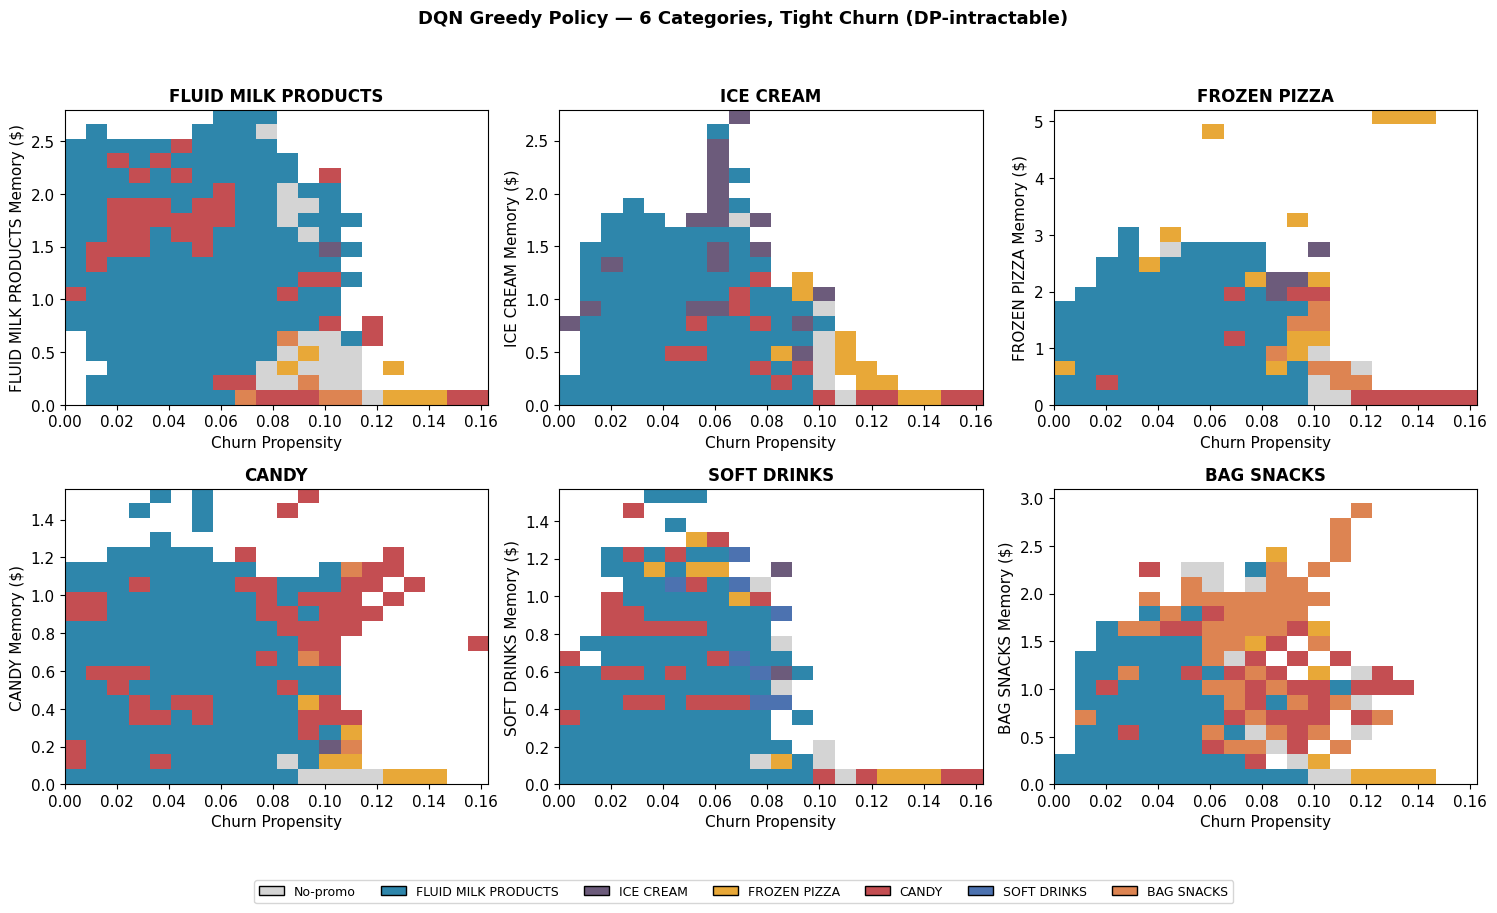

In [39]:
# ── Exp 3b: Summary + Heatmaps ──
print("="*70)
print("  Experiment 3b: 6 Categories, Tight Churn Init")
print("="*70)
r = exp3b_result
print(f"\n  DQN:            {r['dqn']:.2f} ± {r['dqn_se']:.2f}")
print(f"  Greedy-myopic:  {r['myopic']:.2f}")
print(f"  Random:         {r['random']:.2f}")
print(f"  No-promo:       {r['no_promo']:.2f}")
print(f"\n  DQN vs Myopic:  {(r['dqn']/r['myopic'] - 1)*100:+.1f}%")
print(f"  Repeat rate: {r['repeat_rate']:.1%}")
print(f"  Rotation Δ: {r['rotation_delta']:+.1%}")

# Heatmaps
exp3b_action_map = {0: "No-promo"}
for i, cat in enumerate(EXP3_CATEGORIES):
    exp3b_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

fig = plot_policy_heatmaps(
    exp3b_result["dqn_obs_actions"],
    "DQN Greedy Policy — 6 Categories, Tight Churn (DP-intractable)",
    n_products=6, action_map=exp3b_action_map,
)
plt.show()

In [80]:
# ── Exp 3b: Enriched comparison table (for article) ──
env_3b_eval = build_exp3b_env(decouple_memory_init=False)
N_3b = env_3b_eval.N

# Action labels
action_labels_3b = ["None"]
for j in range(N_3b):
    short = env_3b_eval.params[env_3b_eval.products[j]]["category"].split("/")[0].split(" - ")[0]
    action_labels_3b.append(short[:2].upper())

# Myopic action
expected_rev_3b = (
    1 / (1 + np.exp(-(env_3b_eval._beta_0 + env_3b_eval.beta_p * env_3b_eval._raw_deal_signal)))
) * env_3b_eval._prices
myopic_action_3b = int(expected_rev_3b.argmax()) + 1

# Reload DQN agent
agent_3b, _ = train_or_load(
    build_exp3b_env(decouple_memory_init=True, init_memory_frac=0.3),
    label="6cat_1prod_tight_churn",
    n_episodes=10_000, eval_interval=500, eps_decay_steps=50_000, hidden=64,
)
dqn_3b_fn = lambda obs: agent_3b.select_action(obs, greedy=True)

policies_3b = [
    ("No-Promo",      "no_promo"),
    ("Random",        "random"),
    ("Greedy-Myopic", myopic_action_3b),
    ("DQN",           dqn_3b_fn),
]

header_actions = "  ".join(f"{l:>4s}" for l in action_labels_3b)
print(f"{'Policy':<18s}  {'Reward':>10s}  {'Ep Len':>6s}  {'Purch/Step':>10s}  {header_actions}")
print("-" * 100)

for name, policy in policies_3b:
    stats = _rollout(env_3b_eval, n_episodes=500, policy=policy, seed=99)
    mean_r = stats["rewards"].mean()
    mean_len = stats["lengths"].mean()
    purch_rate = stats["purchases_per_step"].mean()
    se = stats["rewards"].std() / np.sqrt(500)
    r_str = f"{mean_r:.2f}" if name != "DQN" else f"{mean_r:.2f}±{se:.2f}"

    actions = stats["actions"]
    counts = np.bincount(actions, minlength=N_3b + 1).astype(float)
    pcts = counts / counts.sum() * 100
    act_str = "  ".join(f"{p:>4.0f}%" for p in pcts)

    print(f"{name:<18s}  {r_str:>10s}  {mean_len:>6.1f}  {purch_rate:>10.2f}  {act_str}")

Training 6cat_1prod_tight_churn:   0%|          | 0/10000 [00:00<?, ?it/s]

  [ep   500] eval=11.18  mean_q=0.43  max_q=0.94  loss=0.0038  eps=0.767
  [ep  1000] eval=10.50  mean_q=0.70  max_q=1.39  loss=0.0045  eps=0.517
  [ep  1500] eval=9.37  mean_q=0.94  max_q=1.85  loss=0.0044  eps=0.263
  [ep  2000] eval=13.11  mean_q=1.08  max_q=2.28  loss=0.0035  eps=0.050
  [ep  2500] eval=11.96  mean_q=1.23  max_q=2.60  loss=0.0036  eps=0.050
  [ep  3000] eval=14.84  mean_q=1.30  max_q=2.88  loss=0.0041  eps=0.050
  [ep  3500] eval=11.08  mean_q=1.33  max_q=3.05  loss=0.0045  eps=0.050
  [ep  4000] eval=14.39  mean_q=1.30  max_q=3.17  loss=0.0047  eps=0.050
  [ep  4500] eval=14.35  mean_q=1.35  max_q=3.35  loss=0.0051  eps=0.050
  [ep  5000] eval=14.55  mean_q=1.35  max_q=3.44  loss=0.0054  eps=0.050
  [ep  5500] eval=17.53  mean_q=1.41  max_q=3.60  loss=0.0057  eps=0.050
  [ep  6000] eval=12.93  mean_q=1.48  max_q=3.79  loss=0.0059  eps=0.050
  [ep  6500] eval=10.44  mean_q=1.51  max_q=4.06  loss=0.0062  eps=0.050
  [ep  7000] eval=10.14  mean_q=1.51  max_q=4.28  lo

In [107]:
# ── Exp 3b: Round-robin & DQN-mix baselines (2000 episodes, full stats) ──

env_3b_rr = build_exp3b_env(decouple_memory_init=False)

# DQN's action distribution from enriched table: None 2%, FM 39%, IC 15%, FP 7%, CA 4%, SD 16%, BA 16%
rr_configs = {
    "RR: FM + SD": [1, 5],
}

dqn_action_probs_3b = np.array([0.02, 0.39, 0.15, 0.07, 0.04, 0.16, 0.17])

eval_seeds = [99, 200, 300, 400]

# Use 2000-episode stability check values for DQN and myopic
dqn_reward_3b = 16.21
myopic_reward_3b = 14.15

print("── Exp 3b: Full Stats for Article Table (2000 episodes) ──\n")
print(f"{'Policy':<22s} {'Reward':>14s} {'Ep Len':>8s} {'P/Step':>8s}")
print("-" * 54)

# Round-robin
for name, action_seq in rr_configs.items():
    all_rewards, all_lengths, all_purch = [], [], []
    for s in eval_seeds:
        def make_rr_policy(seq):
            idx = [0]
            def policy(obs):
                a = seq[idx[0] % len(seq)]
                idx[0] += 1
                return a
            return policy
        stats = _rollout(env_3b_rr, n_episodes=500, policy=make_rr_policy(action_seq), seed=s)
        all_rewards.append(stats["rewards"])
        all_lengths.append(stats["lengths"])
        all_purch.append(stats["purchases_per_step"])
    combined_r = np.concatenate(all_rewards)
    combined_l = np.concatenate(all_lengths)
    combined_p = np.concatenate(all_purch)
    mean_r = combined_r.mean()
    se_r = combined_r.std() / np.sqrt(len(combined_r))
    print(f"  {name:<20s} {mean_r:>6.2f} ± {se_r:.2f} {combined_l.mean():>8.1f} {combined_p.mean():>8.2f}")

# Random DQN-mix
all_rewards, all_lengths, all_purch = [], [], []
for s in eval_seeds:
    np.random.seed(s)
    def random_dqn_mix_3b(obs):
        return int(np.random.choice(7, p=dqn_action_probs_3b))
    stats = _rollout(env_3b_rr, n_episodes=500, policy=random_dqn_mix_3b, seed=s)
    all_rewards.append(stats["rewards"])
    all_lengths.append(stats["lengths"])
    all_purch.append(stats["purchases_per_step"])
combined_r = np.concatenate(all_rewards)
combined_l = np.concatenate(all_lengths)
combined_p = np.concatenate(all_purch)
mix_mean = combined_r.mean()
mix_se = combined_r.std() / np.sqrt(len(combined_r))
print(f"  {'Random DQN-mix':<20s} {mix_mean:>6.2f} ± {mix_se:.2f} {combined_l.mean():>8.1f} {combined_p.mean():>8.2f}")

print(f"\n  DQN vs best RR:        {(dqn_reward_3b/mean_r - 1)*100:+.1f}%")
print(f"  DQN vs random DQN-mix: {(dqn_reward_3b/mix_mean - 1)*100:+.1f}%")

# Save for chart cell
exp3b_rr_results = {name: (mean_r, se_r)}
exp3b_mix_mean, exp3b_mix_se = mix_mean, mix_se

── Exp 3b: Full Stats for Article Table (2000 episodes) ──

Policy                         Reward   Ep Len   P/Step
------------------------------------------------------
  RR: FM + SD           19.40 ± 0.60     35.0     0.39
  Random DQN-mix        14.51 ± 0.43     29.0     0.33

  DQN vs best RR:        -16.4%
  DQN vs random DQN-mix: +11.7%


In [93]:
# ── Exp 3b: Stability check — ALL policies on 2000 eval episodes ──

env_3b_stress = build_exp3b_env(decouple_memory_init=False)

# Reload DQN agent (uses cached best model)
agent_3b_stress, _ = train_or_load(
    build_exp3b_env(decouple_memory_init=True, init_memory_frac=0.3),
    label="6cat_1prod_tight_churn",
    n_episodes=10_000, eval_interval=500, eval_episodes=200,
    eps_decay_steps=50_000, buffer_size=400_000, hidden=64,
)
dqn_3b_stress_fn = lambda obs: agent_3b_stress.select_action(obs, greedy=True)

# Myopic action
expected_rev_3b_stress = (
    1 / (1 + np.exp(-(env_3b_stress._beta_0 + env_3b_stress.beta_p * env_3b_stress._raw_deal_signal)))
) * env_3b_stress._prices
myopic_action_3b_stress = int(expected_rev_3b_stress.argmax()) + 1

seeds = [99, 200, 300, 400]

for label, make_policy in [
    ("No-Promo", lambda s: "no_promo"),
    ("Random", lambda s: "random"),
    ("Greedy-Myopic", lambda s: myopic_action_3b_stress),
    ("DQN", lambda s: dqn_3b_stress_fn),
]:
    all_rewards = []
    print(f"\n── {label} ──")
    for s in seeds:
        policy = make_policy(s)
        stats = _rollout(env_3b_stress, n_episodes=500, policy=policy, seed=s)
        mean_r = stats["rewards"].mean()
        se = stats["rewards"].std() / np.sqrt(500)
        all_rewards.append(stats["rewards"])
        print(f"  Seed {s}: {mean_r:.2f} ± {se:.2f}  (ep_len={stats['lengths'].mean():.1f})")

    combined = np.concatenate(all_rewards)
    combined_se = combined.std() / np.sqrt(len(combined))
    print(f"  Combined (2000 eps): {combined.mean():.2f} ± {combined_se:.2f}")

print("\n── Summary ──")
print("  Use these 2000-episode estimates for the article.")

  Loaded final model ← 6cat_1prod_tight_churn_79db8cd1c056.pt (step 270,586)

── No-Promo ──
  Seed 99: 7.16 ± 0.50  (ep_len=20.9)
  Seed 200: 7.00 ± 0.51  (ep_len=20.9)
  Seed 300: 6.99 ± 0.50  (ep_len=21.0)
  Seed 400: 7.11 ± 0.50  (ep_len=20.8)
  Combined (2000 eps): 7.06 ± 0.25

── Random ──
  Seed 99: 10.64 ± 0.70  (ep_len=24.3)
  Seed 200: 11.05 ± 0.67  (ep_len=25.9)
  Seed 300: 10.21 ± 0.60  (ep_len=24.9)
  Seed 400: 9.30 ± 0.59  (ep_len=23.1)
  Combined (2000 eps): 10.30 ± 0.32

── Greedy-Myopic ──
  Seed 99: 14.52 ± 0.73  (ep_len=30.1)
  Seed 200: 14.78 ± 0.76  (ep_len=30.5)
  Seed 300: 14.10 ± 0.74  (ep_len=29.4)
  Seed 400: 13.19 ± 0.64  (ep_len=28.1)
  Combined (2000 eps): 14.15 ± 0.36

── DQN ──
  Seed 99: 16.46 ± 0.92  (ep_len=31.7)
  Seed 200: 16.47 ± 0.94  (ep_len=31.5)
  Seed 300: 15.95 ± 0.90  (ep_len=31.2)
  Seed 400: 15.95 ± 0.89  (ep_len=30.7)
  Combined (2000 eps): 16.21 ± 0.46

── Summary ──
  Use these 2000-episode estimates for the article.


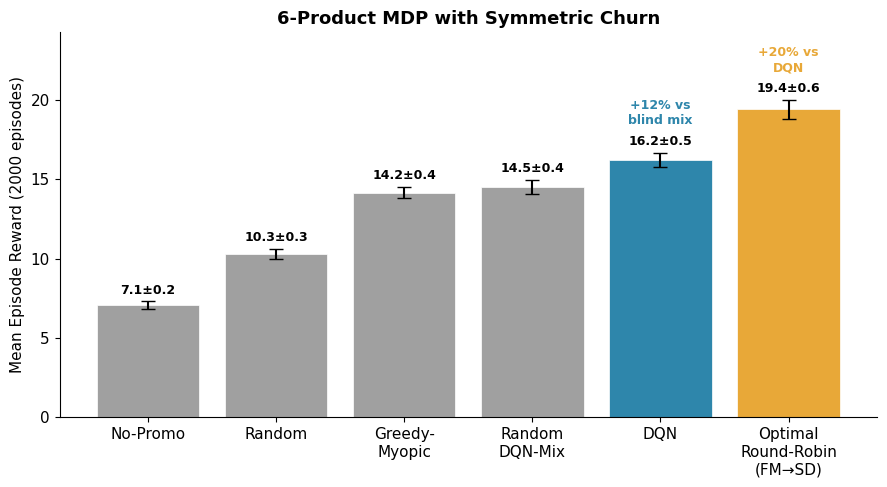

Saved → submissions/exp3b_results.png


In [106]:
# ── Exp 3b: Bar chart with error bounds (for article) ──
import matplotlib.pyplot as plt

# 2000-episode validated results (4 seeds × 500 episodes each)
rr_fm_sd_mean, rr_fm_sd_se = exp3b_rr_results["RR: FM + SD"]

policies_3b_chart = [
    ("No-Promo",                          7.06, 0.25),
    ("Random",                           10.30, 0.32),
    ("Greedy-\nMyopic",                  14.15, 0.36),
    ("Random\nDQN-Mix",                  exp3b_mix_mean, exp3b_mix_se),
    ("DQN",                              16.21, 0.46),
    ("Optimal\nRound-Robin\n(FM→SD)",    rr_fm_sd_mean, rr_fm_sd_se),
]

labels = [p[0] for p in policies_3b_chart]
means = [p[1] for p in policies_3b_chart]
errors = [p[2] for p in policies_3b_chart]

C_GRAY = "#A0A0A0"
C_BLUE = "#2E86AB"
C_ORANGE = "#E8A838"
colors = [C_GRAY, C_GRAY, C_GRAY, C_GRAY, C_BLUE, C_ORANGE]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, means, yerr=errors, capsize=5, color=colors, edgecolor="white", linewidth=0.5)

# Add value labels on bars
for bar, m, e in zip(bars, means, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + e + 0.3,
            f"{m:.1f}±{e:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Mean Episode Reward (2000 episodes)", fontsize=11)
ax.set_title("6-Product MDP with Symmetric Churn", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(means) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotations: DQN vs blind mix, Optimal RR vs DQN
ax.annotate(f"+{(16.21/exp3b_mix_mean - 1)*100:.0f}% vs\nblind mix", xy=(4, 16.21 + 0.46 + 1.8),
            fontsize=9, ha="center", color=C_BLUE, fontweight="bold")
ax.annotate(f"+{(rr_fm_sd_mean/16.21 - 1)*100:.0f}% vs\nDQN", xy=(5, rr_fm_sd_mean + rr_fm_sd_se + 1.8),
            fontsize=9, ha="center", color=C_ORANGE, fontweight="bold")

plt.tight_layout()
plt.savefig("../submissions/exp3b_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → submissions/exp3b_results.png")

In [40]:
# ── Exp 3c: Asymmetric churn recovery ──
# Purchase recovers churn 5x faster than no-purchase degrades it.
# Rationale: a customer buying is a strong engagement signal;
# not buying for one week is a weak disengagement signal.

def build_exp3c_env(decouple_memory_init=True, init_memory_frac=0.3):
    """Exp 3 env with asymmetric churn: eta_up=0.002, eta_down=0.01."""
    cal = exp3_calibrations
    product_ids, beta_0_list, beta_m_list, beta_p_list, beta_l_list = [], [], [], [], []
    categories, prices, deal_signals = [], [], []

    for cat in EXP3_CATEGORIES:
        r = cal[cat]
        pid = exp3_products[cat][0]
        product_ids.append(pid)
        beta_0_list.append(r["intercepts"][0])
        beta_m_list.append(r["beta_m"])
        beta_p_list.append(r["beta_p"])
        beta_l_list.append(r["beta_l"])
        categories.append(cat)
        pid_txn = merged[merged["product_id"] == pid]
        price = float(pid_txn["sales_value"].median())
        prices.append(price)
        deal_signals.append(price * DELTA)

    pp = {}
    for i, pid in enumerate(product_ids):
        pp[pid] = {
            "beta_0": beta_0_list[i],
            "raw_deal_signal": deal_signals[i],
            "price": prices[i],
            "category": categories[i],
        }

    env = DiscountEnv(
        product_params=pp, product_order=product_ids,
        beta_p=np.array(beta_p_list), beta_l=np.array(beta_l_list),
        beta_m=np.array(beta_m_list), alpha=ALPHA,
        c0=V2_C0, eta=V2_ETA, churn_cost=0.0,
        decouple_memory_init=decouple_memory_init,
        init_memory_frac=init_memory_frac,
    )

    # Patch step to use asymmetric churn recovery
    eta_up = V2_ETA       # 0.002 per no-purchase step
    eta_down = 5 * V2_ETA # 0.01 per purchase step
    original_step = env.step

    def patched_step(action):
        obs, reward, terminated, truncated, info = original_step(action)
        # The base step used symmetric eta. Fix the churn update.
        churn, mem, rec = env._state
        if info["purchases"].any():
            # Undo symmetric recovery, apply asymmetric
            corrected_churn = max(0.0, churn + env.eta - eta_down)
            env._state = (corrected_churn, mem, rec)
        return env._get_state(), reward, terminated, truncated, info

    env.step = patched_step
    return env

# Quick check episode lengths
_env = build_exp3c_env(decouple_memory_init=False)
_stats = _rollout(_env, n_episodes=500, policy='random', seed=42)
print(f"Exp 3c episode lengths: mean={_stats['lengths'].mean():.1f}  "
      f"median={np.median(_stats['lengths']):.0f}  "
      f"reward={_stats['rewards'].mean():.2f}")

exp3c_result = run_experiment(
    env_fn=lambda **kw: build_exp3c_env(**kw),
    label="6cat_1prod_asym_churn",
    n_episodes=10_000, eps_decay_steps=50_000, hidden=64,
)

Exp 3c episode lengths: mean=33.7  median=10  reward=14.83

  6cat_1prod_asym_churn

  ── Baselines ──
  No-promo:       7.65
  Random:         16.44
  Greedy-myopic:  21.45  (always FLUID MILK PRODUCTS)


Training 6cat_1prod_asym_churn:   0%|          | 0/10000 [00:00<?, ?it/s]

  [ep   500] eval=24.24  mean_q=0.55  max_q=0.94  loss=0.0036  eps=0.627
  [ep  1000] eval=23.42  mean_q=0.82  max_q=1.88  loss=0.0031  eps=0.189
  [ep  1500] eval=24.75  mean_q=1.00  max_q=2.61  loss=0.0026  eps=0.050
  [ep  2000] eval=33.73  mean_q=1.24  max_q=3.34  loss=0.0035  eps=0.050
  [ep  2500] eval=29.99  mean_q=1.37  max_q=3.85  loss=0.0041  eps=0.050
  [ep  3000] eval=27.83  mean_q=1.41  max_q=4.21  loss=0.0045  eps=0.050
  [ep  3500] eval=25.93  mean_q=1.53  max_q=4.42  loss=0.0049  eps=0.050
  [ep  4000] eval=27.66  mean_q=1.65  max_q=4.76  loss=0.0052  eps=0.050
  [ep  4500] eval=28.77  mean_q=1.72  max_q=5.16  loss=0.0056  eps=0.050
  [ep  5000] eval=28.20  mean_q=1.62  max_q=5.22  loss=0.0057  eps=0.050
  [ep  5500] eval=15.08  mean_q=1.65  max_q=5.37  loss=0.0056  eps=0.050
  [ep  6000] eval=28.87  mean_q=1.76  max_q=5.74  loss=0.0058  eps=0.050
  [ep  6500] eval=24.46  mean_q=1.70  max_q=5.67  loss=0.0058  eps=0.050
  [ep  7000] eval=30.04  mean_q=1.79  max_q=5.82  l

  Experiment 3c: 6 Categories, Asymmetric Churn Recovery

  DQN:            33.94 ± 2.10
  Greedy-myopic:  21.45
  Random:         16.44
  No-promo:       7.65

  DQN vs Myopic:  +58.2%
  Repeat rate: 41.9%
  Rotation Δ: -12.3%


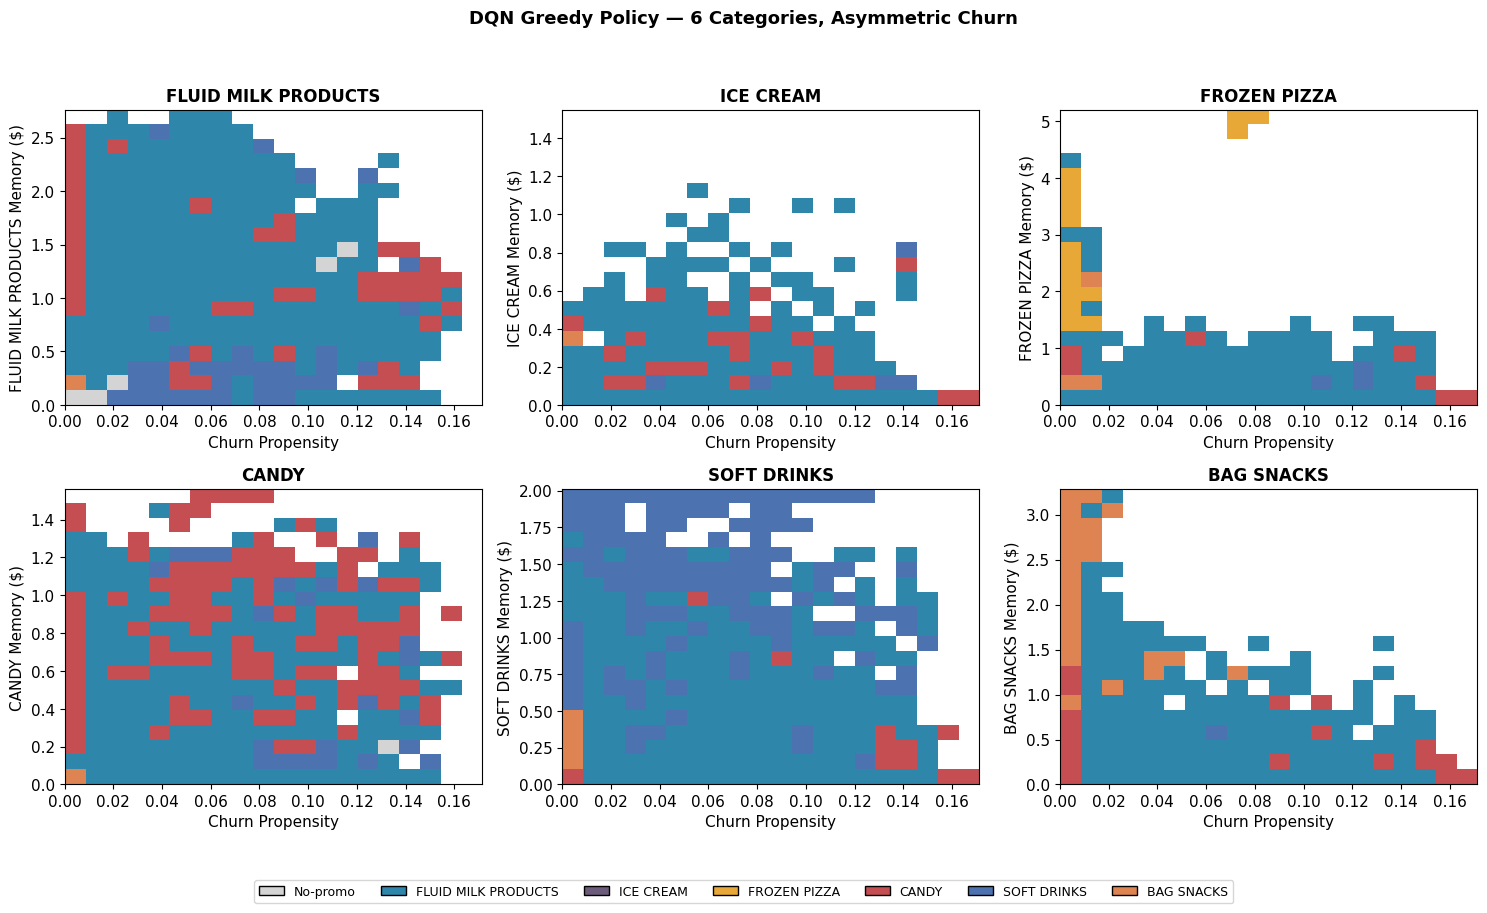


── Policy Table: Action Distribution by Churn × Category Memory ──

  FLUID MILK PRODUCTS (β_m=0.94):
  churn \ mem   mem<0.74  mem<1.15  mem<2.76
  c<0.002       BAG SNACKS  49%    CANDY  45%    CANDY  45%
  c<0.006       FLUID MILK PRODUCTS  36%  FLUID MILK PRODUCTS  34%  FLUID MILK PRODUCTS  40%
  c<0.018       FLUID MILK PRODUCTS  52%  FLUID MILK PRODUCTS  58%  FLUID MILK PRODUCTS  46%
  c<0.171       FLUID MILK PRODUCTS  40%  FLUID MILK PRODUCTS  48%  FLUID MILK PRODUCTS  56%

  ICE CREAM (β_m=0.82):
  churn \ mem   mem<1.55
  c<0.002         CANDY  39%
  c<0.006       FLUID MILK PRODUCTS  36%
  c<0.018       FLUID MILK PRODUCTS  51%
  c<0.171       FLUID MILK PRODUCTS  49%

  FROZEN PIZZA (β_m=0.41):
  churn \ mem   mem<5.20
  c<0.002         CANDY  39%
  c<0.006       FLUID MILK PRODUCTS  36%
  c<0.018       FLUID MILK PRODUCTS  51%
  c<0.171       FLUID MILK PRODUCTS  49%

  CANDY (β_m=2.19):
  churn \ mem   mem<0.02  mem<0.61  mem<1.56
  c<0.002       BAG SNACKS  42%    CANDY

In [43]:
# ── Exp 3c: Summary + Heatmaps ──
print("="*70)
print("  Experiment 3c: 6 Categories, Asymmetric Churn Recovery")
print("="*70)
r = exp3c_result
print(f"\n  DQN:            {r['dqn']:.2f} ± {r['dqn_se']:.2f}")
print(f"  Greedy-myopic:  {r['myopic']:.2f}")
print(f"  Random:         {r['random']:.2f}")
print(f"  No-promo:       {r['no_promo']:.2f}")
print(f"\n  DQN vs Myopic:  {(r['dqn']/r['myopic'] - 1)*100:+.1f}%")
print(f"  Repeat rate: {r['repeat_rate']:.1%}")
print(f"  Rotation Δ: {r['rotation_delta']:+.1%}")

exp3c_action_map = {0: "No-promo"}
for i, cat in enumerate(EXP3_CATEGORIES):
    exp3c_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

fig = plot_policy_heatmaps(
    exp3c_result["dqn_obs_actions"],
    "DQN Greedy Policy — 6 Categories, Asymmetric Churn",
    n_products=6, action_map=exp3c_action_map,
)
plt.show()

# ── Textual policy summary: action distribution by churn × memory bins ──
print("\n── Policy Table: Action Distribution by Churn × Category Memory ──")
states = np.array([o for o, _ in exp3c_result["dqn_obs_actions"]])
actions = np.array([a for _, a in exp3c_result["dqn_obs_actions"]])
churn_vals = states[:, 0]
N = 6

# Bin churn into 5 quantile bins
churn_edges = np.quantile(churn_vals, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
churn_edges = np.unique(churn_edges)
churn_bin_idx = np.clip(np.digitize(churn_vals, churn_edges[1:]), 0, len(churn_edges) - 2)

action_names = [exp3c_action_map.get(a, f"act_{a}") for a in range(N + 1)]

for cat_idx, cat in enumerate(EXP3_CATEGORIES):
    short = cat.split("/")[0].split(" - ")[0]
    prod_indices = [cat_idx]
    cat_mem = states[:, 1 + cat_idx]
    mem_edges = np.quantile(cat_mem, [0, 0.33, 0.67, 1.0])
    mem_edges = np.unique(mem_edges)
    mem_bin_idx = np.clip(np.digitize(cat_mem, mem_edges[1:]), 0, len(mem_edges) - 2)

    print(f"\n  {short} (β_m={exp3_calibrations[cat]['beta_m']:.2f}):")
    print(f"  {'churn \\ mem':<12s}", end="")
    for mi in range(len(mem_edges) - 1):
        print(f"  mem<{mem_edges[mi+1]:.2f}", end="")
    print()

    for ci in range(len(churn_edges) - 1):
        churn_label = f"c<{churn_edges[ci+1]:.3f}"
        print(f"  {churn_label:<12s}", end="")
        for mi in range(len(mem_edges) - 1):
            mask = (churn_bin_idx == ci) & (mem_bin_idx == mi)
            if mask.sum() < 5:
                print(f"  {'(few)':>10s}", end="")
                continue
            counts = np.bincount(actions[mask], minlength=N + 1)
            top_action = counts.argmax()
            top_pct = counts[top_action] / counts.sum() * 100
            print(f"  {action_names[top_action]:>7s} {top_pct:>3.0f}%", end="")
        print()

print(f"\n  Total obs-action pairs: {len(actions):,}")

In [44]:
# ── Exp 3c: Round-robin baselines to test if DQN learned state-dependence ──

env_3c = build_exp3c_env(decouple_memory_init=False)

# Round-robin across DQN's top actions (FM=1, CANDY=4, BAG SNACKS=6, SOFT DRINKS=5)
rr_configs = {
    "RR: FM only (=myopic)": [1],
    "RR: FM + CANDY": [1, 4],
    "RR: FM + CANDY + BAG": [1, 4, 6],
    "RR: FM + CANDY + BAG + SD": [1, 4, 6, 5],
    "RR: all 6 products": [1, 2, 3, 4, 5, 6],
    "RR: DQN mix (35/27/19/12)": [1]*35 + [4]*27 + [6]*19 + [5]*12 + [0]*6 + [3]*1,
}

print("── Round-Robin Baselines (Exp 3c env) ──")
print(f"  {'Policy':<35s} {'Reward':>8s} {'vs Myopic':>10s}")
print("-" * 55)

myopic_reward = exp3c_result["myopic"]
dqn_reward = exp3c_result["dqn"]

for name, action_seq in rr_configs.items():
    step_counter = [0]
    def make_rr_policy(seq):
        idx = [0]
        def policy(obs):
            a = seq[idx[0] % len(seq)]
            idx[0] += 1
            return a
        return policy

    stats = run_rollout(env_3c, n_episodes=N_EVAL_ROLLOUT,
                        policy=make_rr_policy(action_seq), seed=99)
    mean_r = stats["rewards"].mean()
    vs_myopic = (mean_r / myopic_reward - 1) * 100
    print(f"  {name:<35s} {mean_r:>8.2f} {vs_myopic:>+9.1f}%")

print(f"\n  {'DQN (state-dependent)':<35s} {dqn_reward:>8.2f} {(dqn_reward/myopic_reward - 1)*100:>+9.1f}%")
print(f"  {'Greedy-myopic':<35s} {myopic_reward:>8.2f} {0.0:>+9.1f}%")

── Round-Robin Baselines (Exp 3c env) ──
  Policy                                Reward  vs Myopic
-------------------------------------------------------
  RR: FM only (=myopic)                  21.45      +0.0%
  RR: FM + CANDY                         29.15     +35.9%
  RR: FM + CANDY + BAG                   29.99     +39.8%
  RR: FM + CANDY + BAG + SD              25.50     +18.9%
  RR: all 6 products                     18.49     -13.8%
  RR: DQN mix (35/27/19/12)              14.19     -33.9%

  DQN (state-dependent)                  33.94     +58.2%
  Greedy-myopic                          21.45      +0.0%


In [45]:
# ── Randomized static policy: same action PROBABILITIES as DQN, no state conditioning ──
# This is the fair test of whether DQN's value comes from state-dependence or just the mix.

env_3c_test = build_exp3c_env(decouple_memory_init=False)

# DQN's observed action frequencies: FM=35.2%, CANDY=27.3%, BAG=19.1%, SD=12.2%, No-promo=5.5%, FP=0.8%, IC=0%
dqn_probs = np.array([0.055, 0.352, 0.000, 0.008, 0.273, 0.122, 0.191])
dqn_probs = dqn_probs / dqn_probs.sum()  # normalize

def make_random_mix_policy(probs, seed=42):
    rng = np.random.RandomState(seed)
    def policy(obs):
        return int(rng.choice(len(probs), p=probs))
    return policy

# Run multiple seeds to get stable estimate
rewards = []
for s in range(10):
    stats = run_rollout(env_3c_test, n_episodes=N_EVAL_ROLLOUT,
                        policy=make_random_mix_policy(dqn_probs, seed=s), seed=99+s)
    rewards.append(stats["rewards"].mean())

random_mix_mean = np.mean(rewards)
random_mix_se = np.std(rewards) / np.sqrt(len(rewards))

print("── State-Dependence Test ──")
print(f"  DQN (state-dependent):     {exp3c_result['dqn']:.2f} ± {exp3c_result['dqn_se']:.2f}")
print(f"  Random DQN-mix (no state): {random_mix_mean:.2f} ± {random_mix_se:.2f}")
print(f"  Best round-robin (FM+C+B): 29.99")
print(f"  Greedy-myopic (FM only):   {exp3c_result['myopic']:.2f}")
print(f"\n  DQN vs Random-mix:  {(exp3c_result['dqn']/random_mix_mean - 1)*100:+.1f}%")
print(f"  DQN vs Best RR:     {(exp3c_result['dqn']/29.99 - 1)*100:+.1f}%")
print(f"\n  If DQN >> Random-mix: state-dependence matters")
print(f"  If DQN ≈ Random-mix: DQN just learned the right mix")

── State-Dependence Test ──
  DQN (state-dependent):     33.94 ± 2.10
  Random DQN-mix (no state): 26.68 ± 0.49
  Best round-robin (FM+C+B): 29.99
  Greedy-myopic (FM only):   21.45

  DQN vs Random-mix:  +27.2%
  DQN vs Best RR:     +13.2%

  If DQN >> Random-mix: state-dependence matters
  If DQN ≈ Random-mix: DQN just learned the right mix


In [85]:
# ── Exp 3c: Enriched comparison table (for article) ──
# Match original run_experiment config exactly, but ADD best-model selection
env_3c_eval = build_exp3c_env(decouple_memory_init=False)
N_3c = env_3c_eval.N

# Action labels
action_labels_3c = ["None"]
for j in range(N_3c):
    short = env_3c_eval.params[env_3c_eval.products[j]]["category"].split("/")[0].split(" - ")[0]
    action_labels_3c.append(short[:2].upper())

# Myopic action
expected_rev_3c = (
    1 / (1 + np.exp(-(env_3c_eval._beta_0 + env_3c_eval.beta_p * env_3c_eval._raw_deal_signal)))
) * env_3c_eval._prices
myopic_action_3c = int(expected_rev_3c.argmax()) + 1

# Original config: hidden=64, eps_decay=50K, n_episodes=10K, buffer=400K
agent_3c, _ = train_or_load(
    build_exp3c_env(decouple_memory_init=True, init_memory_frac=0.3),
    label="6cat_1prod_asym_churn",
    n_episodes=10_000, eval_interval=500, eval_episodes=200,
    eps_decay_steps=50_000, buffer_size=400_000, hidden=64,
)
dqn_3c_fn = lambda obs: agent_3c.select_action(obs, greedy=True)

# Best round-robin policy (FM + Candy + Bag Snacks)
rr_best_seq = [1, 4, 6]
rr_idx = [0]
def rr_best_fn(obs):
    a = rr_best_seq[rr_idx[0] % len(rr_best_seq)]
    rr_idx[0] += 1
    return a

# Random DQN-mix (same frequencies, no state) — placeholder probs
dqn_probs_3c = np.array([0.055, 0.352, 0.000, 0.008, 0.273, 0.122, 0.191])
dqn_probs_3c = dqn_probs_3c / dqn_probs_3c.sum()
mix_rng = np.random.RandomState(42)
def random_mix_fn(obs):
    return int(mix_rng.choice(len(dqn_probs_3c), p=dqn_probs_3c))

policies_3c = [
    ("No-Promo",        "no_promo"),
    ("Random",          "random"),
    ("Greedy-Myopic",   myopic_action_3c),
    ("Best Round-Robin", rr_best_fn),
    ("Random DQN-Mix",  random_mix_fn),
    ("DQN",             dqn_3c_fn),
]

header_actions = "  ".join(f"{l:>4s}" for l in action_labels_3c)
print(f"{'Policy':<20s}  {'Reward':>10s}  {'Ep Len':>6s}  {'Purch/Step':>10s}  {header_actions}")
print("-" * 110)

for name, policy in policies_3c:
    stats = _rollout(env_3c_eval, n_episodes=500, policy=policy, seed=99)
    mean_r = stats["rewards"].mean()
    mean_len = stats["lengths"].mean()
    purch_rate = stats["purchases_per_step"].mean()
    se = stats["rewards"].std() / np.sqrt(500)
    r_str = f"{mean_r:.2f}" if name != "DQN" else f"{mean_r:.2f}±{se:.2f}"

    actions = stats["actions"]
    counts = np.bincount(actions, minlength=N_3c + 1).astype(float)
    pcts = counts / counts.sum() * 100
    act_str = "  ".join(f"{p:>4.0f}%" for p in pcts)

    print(f"{name:<20s}  {r_str:>10s}  {mean_len:>6.1f}  {purch_rate:>10.2f}  {act_str}")

  Loaded final model ← 6cat_1prod_asym_churn_79db8cd1c056.pt (step 514,604)
Policy                    Reward  Ep Len  Purch/Step  None    FL    IC    FR    CA    SO    BA
--------------------------------------------------------------------------------------------------------------
No-Promo                    7.65    21.0        0.19   100%     0%     0%     0%     0%     0%     0%
Random                     17.39    36.8        0.29    14%    14%    14%    14%    14%    15%    14%
Greedy-Myopic              21.45    48.6        0.30     0%   100%     0%     0%     0%     0%     0%
Best Round-Robin           29.99    57.6        0.35     0%    33%     0%     0%    33%     0%    33%
Random DQN-Mix             29.08    56.6        0.34     5%    35%     0%     1%    27%    12%    19%
DQN                   34.48±2.13    65.9        0.35     5%    35%     0%     1%    26%    14%    19%


In [89]:
# ── Exp 3c: Stability check — ALL policies on 2000 eval episodes ──
# Confirm all results are stable across multiple seeds.

env_3c_stress = build_exp3c_env(decouple_memory_init=False)
dqn_3c_stress_fn = lambda obs: agent_3c.select_action(obs, greedy=True)

# Round-robin (FM + Candy + Bag Snacks)
def make_rr_fn():
    seq = [1, 4, 6]
    idx = [0]
    def fn(obs):
        a = seq[idx[0] % len(seq)]
        idx[0] += 1
        return a
    return fn

# Random DQN-mix (same action frequencies, no state)
dqn_mix_probs = np.array([0.055, 0.352, 0.000, 0.008, 0.273, 0.122, 0.191])
dqn_mix_probs = dqn_mix_probs / dqn_mix_probs.sum()
def make_mix_fn(seed):
    rng = np.random.RandomState(seed)
    def fn(obs):
        return int(rng.choice(len(dqn_mix_probs), p=dqn_mix_probs))
    return fn

# Myopic action
expected_rev_3c_stress = (
    1 / (1 + np.exp(-(env_3c_stress._beta_0 + env_3c_stress.beta_p * env_3c_stress._raw_deal_signal)))
) * env_3c_stress._prices
myopic_action_3c_stress = int(expected_rev_3c_stress.argmax()) + 1

seeds = [99, 200, 300, 400]

for label, make_policy in [
    ("No-Promo", lambda s: "no_promo"),
    ("Random", lambda s: "random"),
    ("Greedy-Myopic", lambda s: myopic_action_3c_stress),
    ("Best Round-Robin", lambda s: make_rr_fn()),
    ("Random DQN-Mix", lambda s: make_mix_fn(s)),
    ("DQN", lambda s: dqn_3c_stress_fn),
]:
    all_rewards = []
    print(f"\n── {label} ──")
    for s in seeds:
        policy = make_policy(s)
        stats = _rollout(env_3c_stress, n_episodes=500, policy=policy, seed=s)
        mean_r = stats["rewards"].mean()
        se = stats["rewards"].std() / np.sqrt(500)
        all_rewards.append(stats["rewards"])
        print(f"  Seed {s}: {mean_r:.2f} ± {se:.2f}  (ep_len={stats['lengths'].mean():.1f})")

    combined = np.concatenate(all_rewards)
    combined_se = combined.std() / np.sqrt(len(combined))
    print(f"  Combined (2000 eps): {combined.mean():.2f} ± {combined_se:.2f}")

print("\n── Summary ──")
print("  Use these 2000-episode estimates for the article.")


── No-Promo ──
  Seed 99: 7.65 ± 0.80  (ep_len=21.0)
  Seed 200: 9.42 ± 0.91  (ep_len=25.1)
  Seed 300: 9.42 ± 0.90  (ep_len=25.3)
  Seed 400: 9.36 ± 0.92  (ep_len=25.3)
  Combined (2000 eps): 8.96 ± 0.44

── Random ──
  Seed 99: 18.96 ± 1.60  (ep_len=40.3)
  Seed 200: 17.88 ± 1.46  (ep_len=38.9)
  Seed 300: 19.82 ± 1.63  (ep_len=42.5)
  Seed 400: 18.21 ± 1.50  (ep_len=39.6)
  Combined (2000 eps): 18.72 ± 0.78

── Greedy-Myopic ──
  Seed 99: 21.45 ± 1.38  (ep_len=48.6)
  Seed 200: 20.97 ± 1.36  (ep_len=48.1)
  Seed 300: 20.83 ± 1.36  (ep_len=47.9)
  Seed 400: 20.56 ± 1.33  (ep_len=48.0)
  Combined (2000 eps): 20.95 ± 0.68

── Best Round-Robin ──
  Seed 99: 29.99 ± 2.03  (ep_len=57.6)
  Seed 200: 31.60 ± 2.05  (ep_len=61.5)
  Seed 300: 31.23 ± 2.03  (ep_len=61.4)
  Seed 400: 29.75 ± 1.96  (ep_len=59.1)
  Combined (2000 eps): 30.64 ± 1.01

── Random DQN-Mix ──
  Seed 99: 27.57 ± 1.99  (ep_len=53.4)
  Seed 200: 27.41 ± 1.94  (ep_len=53.2)
  Seed 300: 32.52 ± 2.07  (ep_len=62.7)
  Seed 40

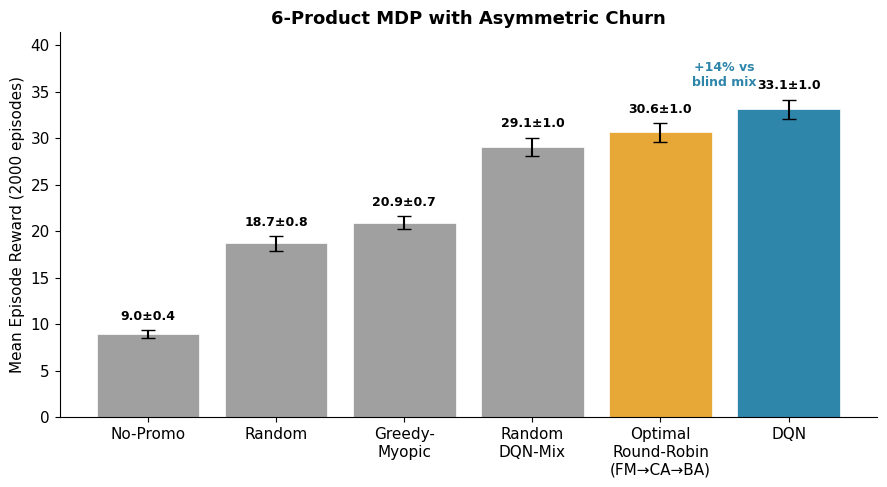

Saved → submissions/exp3c_results.png


In [105]:
# ── Exp 3c: Bar chart with error bounds (for article) ──
import matplotlib.pyplot as plt

# 2000-episode validated results (4 seeds × 500 episodes each)
policies_3c_chart = [
    ("No-Promo",                        8.96, 0.44),
    ("Random",                         18.72, 0.78),
    ("Greedy-\nMyopic",                20.95, 0.68),
    ("Random\nDQN-Mix",                29.06, 0.99),
    ("Optimal\nRound-Robin\n(FM→CA→BA)", 30.64, 1.01),
    ("DQN",                            33.12, 1.04),
]

labels = [p[0] for p in policies_3c_chart]
means = [p[1] for p in policies_3c_chart]
errors = [p[2] for p in policies_3c_chart]

C_GRAY = "#A0A0A0"
C_BLUE = "#2E86AB"
C_ORANGE = "#E8A838"
colors = [C_GRAY, C_GRAY, C_GRAY, C_GRAY, C_ORANGE, C_BLUE]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, means, yerr=errors, capsize=5, color=colors, edgecolor="white", linewidth=0.5)

# Add value labels on bars
for bar, m, e in zip(bars, means, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + e + 0.8,
            f"{m:.1f}±{e:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Mean Episode Reward (2000 episodes)", fontsize=11)
ax.set_title("6-Product MDP with Asymmetric Churn", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(means) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotations
ax.annotate("+14% vs\nblind mix", xy=(4.5, 33.12 + 1.04 + 1.5), fontsize=9, ha="center",
            color=C_BLUE, fontweight="bold")
ax.annotate("+8% vs\noptimal RR", xy=(4.5, 30.64 + 1.01 + 1.5), fontsize=8, ha="center",
            color=C_ORANGE, fontweight="bold", alpha=0.0)  # hidden, DQN annotation covers it

plt.tight_layout()
plt.savefig("../submissions/exp3c_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → submissions/exp3c_results.png")

  Loaded final model ← 6cat_1prod_asym_churn_79db8cd1c056.pt (step 514,604)
Collected 688517 obs-action pairs from 10,000 greedy episodes


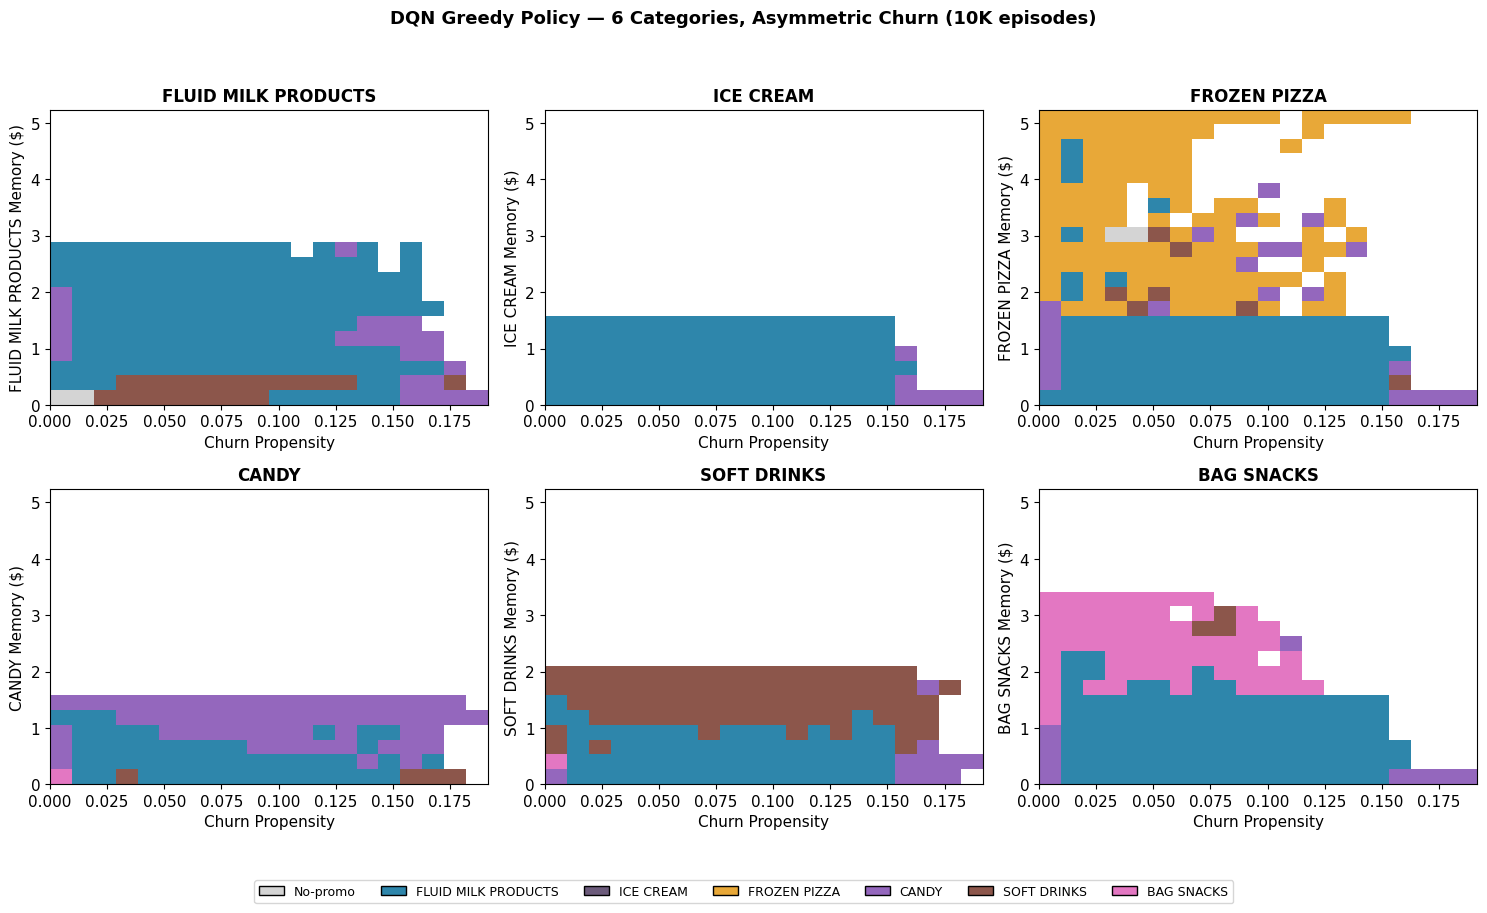

Saved → submissions/exp3c_policy_heatmaps.png


In [121]:
# ── Exp 3c: Policy heatmaps from 10,000-episode greedy rollouts ──

env_3c_heatmap = build_exp3c_env(decouple_memory_init=False)

# Reload DQN agent
agent_3c_heatmap, _ = train_or_load(
    env_3c_heatmap, label="6cat_1prod_asym_churn",
    n_episodes=10_000, eps_decay_steps=50_000, hidden=64,
    buffer_size=400_000, eval_interval=500, eval_episodes=200,
)

# Collect obs-action pairs across 20 seeds × 500 episodes = 10,000 episodes
all_obs_actions = []
for seed in range(0, 10_000, 500):  # 20 seed blocks
    for ep in range(500):
        obs, _ = env_3c_heatmap.reset(seed=seed + ep)
        done = False
        while not done:
            a = agent_3c_heatmap.select_action(obs, greedy=True)
            all_obs_actions.append((obs.copy(), a))
            obs, _, terminated, truncated, _ = env_3c_heatmap.step(a)
            done = terminated or truncated

print(f"Collected {len(all_obs_actions)} obs-action pairs from 10,000 greedy episodes")

# Generate heatmaps with shared y-axis
exp3c_action_map = {0: "No-promo"}
for i, cat in enumerate(EXP3_CATEGORIES):
    exp3c_action_map[i+1] = cat.split("/")[0].split(" - ")[0]

fig = plot_policy_heatmaps(
    all_obs_actions,
    "DQN Greedy Policy — 6 Categories, Asymmetric Churn (10K episodes)",
    n_products=6, action_map=exp3c_action_map, shared_ylim=True,
)
plt.savefig("../submissions/exp3c_policy_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → submissions/exp3c_policy_heatmaps.png")

In [110]:
# ── Exp 3c: Cross-product memory analysis for "anti-rotation" ──
# When a product is promoted at high own-memory, what do other products' memories look like?

states = np.array([o for o, _ in all_obs_actions])
actions = np.array([a for _, a in all_obs_actions])

cat_names = ["FM", "IC", "FP", "CA", "SD", "BA"]
N = 6

print("── When product X is promoted at HIGH own-memory, what are other memories? ──\n")

for prod_idx in range(N):
    action_id = prod_idx + 1  # action 0 = no-promo
    prod_mem = states[:, 1 + prod_idx]  # memory columns start at index 1
    
    # States where this product is promoted
    mask_promoted = actions == action_id
    if mask_promoted.sum() == 0:
        continue
    
    # High memory = top 25% of this product's memory when promoted
    promoted_mem = prod_mem[mask_promoted]
    high_mem_thresh = np.percentile(promoted_mem, 75)
    
    # Also require low churn
    churn = states[:, 0]
    mask_high_mem_low_churn = mask_promoted & (prod_mem >= high_mem_thresh) & (churn < 0.10)
    n_states = mask_high_mem_low_churn.sum()
    
    if n_states < 10:
        print(f"  {cat_names[prod_idx]}: too few states ({n_states}) at high mem + low churn")
        continue
    
    print(f"  {cat_names[prod_idx]} promoted at high own-memory (≥{high_mem_thresh:.2f}) & low churn (<0.10): {n_states} states")
    
    # Show all product memories for these states
    subset_mems = states[mask_high_mem_low_churn, 1:1+N]
    mean_mems = subset_mems.mean(axis=0)
    
    # Rank by memory
    ranked = sorted(range(N), key=lambda i: mean_mems[i])
    for r, i in enumerate(ranked):
        marker = " ← PROMOTED" if i == prod_idx else ""
        print(f"    {cat_names[i]:<6s} mem={mean_mems[i]:.3f}  (rank {r+1}/{N}){marker}")
    print()

── When product X is promoted at HIGH own-memory, what are other memories? ──

  FM promoted at high own-memory (≥1.27) & low churn (<0.10): 10714 states
    FP     mem=0.019  (rank 1/6)
    IC     mem=0.027  (rank 2/6)
    BA     mem=0.145  (rank 3/6)
    CA     mem=0.293  (rank 4/6)
    SD     mem=0.293  (rank 5/6)
    FM     mem=1.657  (rank 6/6) ← PROMOTED

  IC: too few states (4) at high mem + low churn
  FP promoted at high own-memory (≥2.52) & low churn (<0.10): 350 states
    IC     mem=0.000  (rank 1/6)
    CA     mem=0.076  (rank 2/6)
    SD     mem=0.081  (rank 3/6)
    BA     mem=0.288  (rank 4/6)
    FM     mem=0.523  (rank 5/6)
    FP     mem=3.321  (rank 6/6) ← PROMOTED

  CA promoted at high own-memory (≥0.88) & low churn (<0.10): 8150 states
    IC     mem=0.003  (rank 1/6)
    FP     mem=0.011  (rank 2/6)
    SD     mem=0.041  (rank 3/6)
    BA     mem=0.061  (rank 4/6)
    FM     mem=0.758  (rank 5/6)
    CA     mem=1.030  (rank 6/6) ← PROMOTED

  SD promoted at hig

In [116]:
# ── Exp 3c: Trace episodes where FP gets promoted ──
# Show the full action/state sequence around FP promotions

env_trace = build_exp3c_env(decouple_memory_init=False)
cat_names = ["FM", "IC", "FP", "CA", "SD", "BA"]
action_names = ["None"] + cat_names
FP_ACTION = 3  # action 3 = promote Frozen Pizza

# Search across diverse seeds to find episodes from different initial conditions
fp_episodes = []
for seed in range(0, 5000, 7):
    if len(fp_episodes) >= 3:
        break
    obs, _ = env_trace.reset(seed=seed)
    trajectory = []
    done = False
    has_fp = False
    while not done:
        a = agent_3c_heatmap.select_action(obs, greedy=True)
        q_vals = agent_3c_heatmap.get_q_values(obs)
        if a == FP_ACTION:
            has_fp = True
        next_obs, reward, terminated, truncated, info = env_trace.step(a)
        trajectory.append({
            "obs": obs.copy(),
            "action": a,
            "reward": reward,
            "purchases": info["purchases"].copy(),
            "churn": info["churn"],
            "q_vals": q_vals,
        })
        obs = next_obs
        done = terminated or truncated

    if has_fp:
        fp_episodes.append((seed, trajectory))

for seed, trajectory in fp_episodes:
    print(f"═══ Episode (seed={seed}, len={len(trajectory)}) ═══")
    print(f"{'Step':>4s}  {'Action':<8s}  {'Churn':>5s}  {'Rew':>5s}  {'Purchases':<20s}  {'Memory (FM/IC/FP/CA/SD/BA)'}")
    print("-" * 95)
    for t, step in enumerate(trajectory):
        churn = step["obs"][0]
        mem = step["obs"][1:7]
        action_name = action_names[step["action"]]
        purch_str = ", ".join(cat_names[i] for i in range(6) if step["purchases"][i])
        if not purch_str:
            purch_str = "—"
        mem_str = "  ".join(f"{m:.2f}" for m in mem)
        marker = ""
        if step["action"] == FP_ACTION:
            q = step["q_vals"]
            sorted_idx = np.argsort(q)[::-1]
            second_best = sorted_idx[1]
            gap = q[FP_ACTION] - q[second_best]
            marker = f"  ◄ Q(FP)={q[FP_ACTION]:.3f}, Q({action_names[second_best]})={q[second_best]:.3f}, gap={gap:+.4f}"
        print(f"{t:>4d}  {action_name:<8s}  {churn:>5.3f}  {step['reward']:>5.2f}  {purch_str:<20s}  {mem_str}{marker}")
    print()

print(f"Found {len(fp_episodes)} episodes with FP promotions out of {min(seed//7+1, 5000//7)} searched")

═══ Episode (seed=28, len=200) ═══
Step  Action    Churn    Rew  Purchases             Memory (FM/IC/FP/CA/SD/BA)
-----------------------------------------------------------------------------------------------
   0  FM        0.130   1.32  FM                    0.00  0.00  0.54  0.28  0.00  0.00
   1  FM        0.120   1.32  FM                    0.57  0.00  0.43  0.22  0.00  0.00
   2  FM        0.110   0.00  —                     1.02  0.00  0.35  0.18  0.00  0.00
   3  FM        0.112   0.00  —                     1.38  0.00  0.28  0.14  0.00  0.00
   4  FM        0.114   0.00  —                     1.67  0.00  0.22  0.11  0.00  0.00
   5  FM        0.116   0.00  —                     1.91  0.00  0.18  0.09  0.00  0.00
   6  SD        0.118   0.00  —                     2.09  0.00  0.14  0.07  0.00  0.00
   7  FM        0.120   1.32  FM                    1.67  0.00  0.11  0.06  0.40  0.00
   8  FM        0.110   1.32  FM                    1.91  0.00  0.09  0.05  0.32  0.00
   9  F

Total obs-action pairs: 688,517
Confident (Q-gap ≥ 3%): 15,231 (2.2%)
After memory clip (≤ 1.56): 11,226


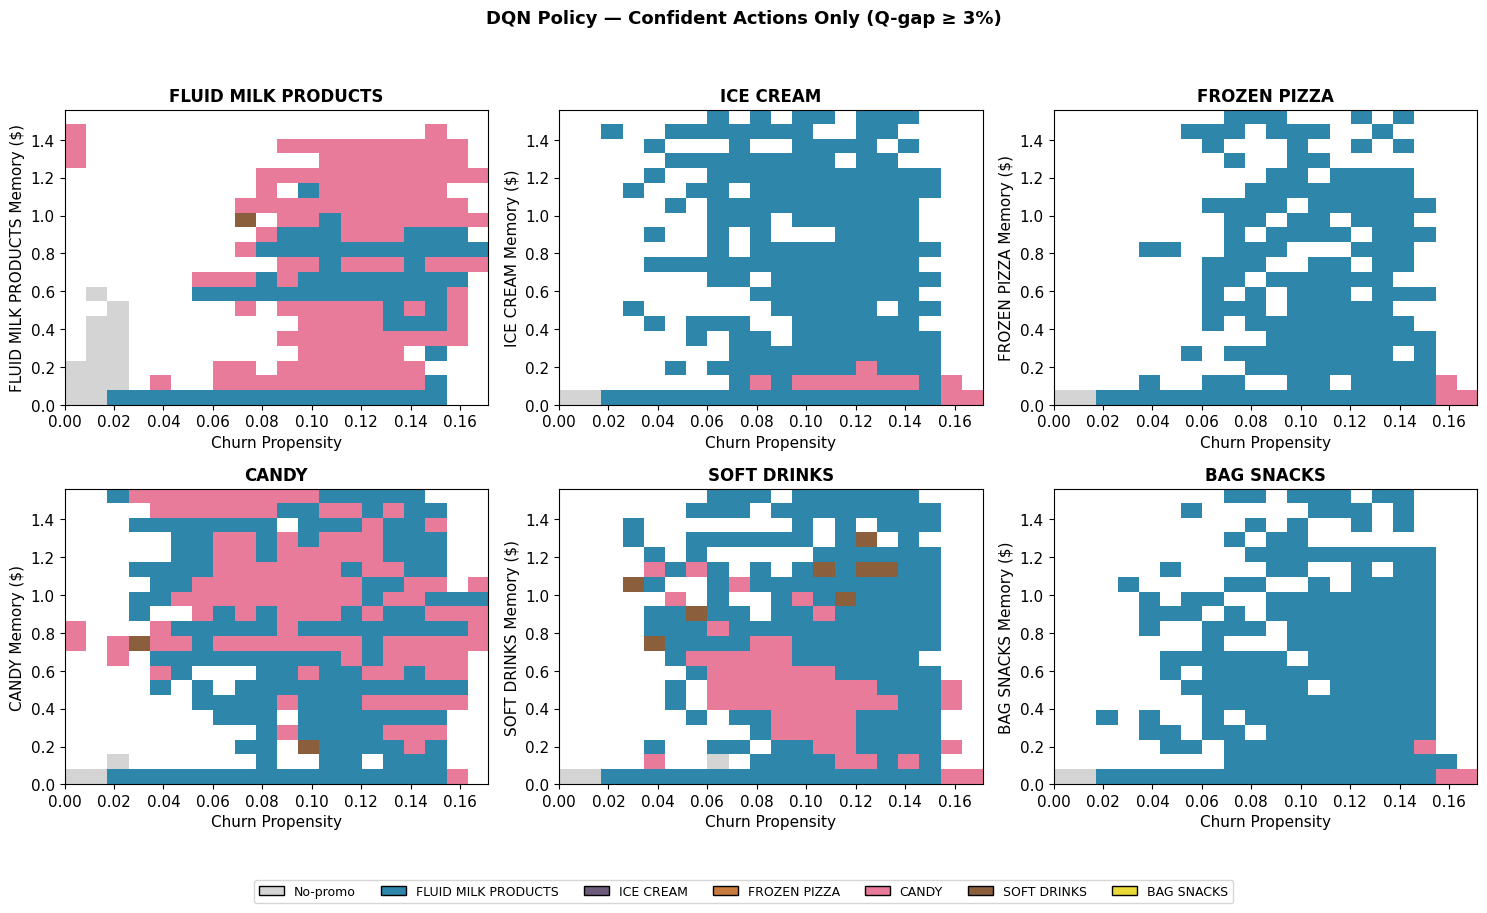

Saved → submissions/exp3c_policy_heatmaps_confident.png


In [136]:
# ── Exp 3c: Confidence-filtered heatmap (Q-gap ≥ 5%, clipped to training range) ──
HEATMAP_COLORS = {
    "No-promo": "#D4D4D4",              # gray
    "FLUID MILK": "#2E86AB",            # blue
    "FLUID MILK PRODUCTS": "#2E86AB",   # blue (alias)
    "ICE CREAM": "#6C5B7B",             # purple
    "FROZEN PIZZA": "#C97B3D",          # brown-ish
    "CANDY": "#E87B9A",                 # pink
    "SOFT DRINKS": "#8B5E3C",           # brown
    "BAG SNACKS": "#E8D838",            # yellow
}

Q_GAP_THRESH = 0.03
MIN_OBS_PER_BIN = 5

# Filter to confident states
filtered_obs_actions = []
for obs, action in all_obs_actions:
    q = agent_3c_heatmap.get_q_values(obs)
    best_q = q.max()
    second_best_q = np.partition(q, -2)[-2]
    gap_pct = (best_q - second_best_q) / (abs(best_q) + 1e-8)
    if gap_pct >= Q_GAP_THRESH:
        filtered_obs_actions.append((obs, action))

# Clip memory to 95th percentile — exclude extreme extrapolation region
all_states = np.array([o for o, _ in all_obs_actions])
mem_clip = np.percentile(all_states[:, 1:7], 95)
clipped = [(obs, a) for obs, a in filtered_obs_actions if obs[1:7].max() <= mem_clip]

print(f"Total obs-action pairs: {len(all_obs_actions):,}")
print(f"Confident (Q-gap ≥ {Q_GAP_THRESH:.0%}): {len(filtered_obs_actions):,} ({len(filtered_obs_actions)/len(all_obs_actions):.1%})")
print(f"After memory clip (≤ {mem_clip:.2f}): {len(clipped):,}")

fig = plot_policy_heatmaps(
    clipped,
    f"DQN Policy — Confident Actions Only (Q-gap ≥ {Q_GAP_THRESH:.0%})",
    n_products=6, action_map=exp3c_action_map, shared_ylim=True,
    min_obs=MIN_OBS_PER_BIN,
)
plt.savefig("../submissions/exp3c_policy_heatmaps_confident.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → submissions/exp3c_policy_heatmaps_confident.png")

In [130]:
# ── Exp 3c: Top-2 vs rest Q-gap analysis (10K sample) ──

action_names = ["None", "FM", "IC", "FP", "CA", "SD", "BA"]

# Random subsample for speed
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(all_obs_actions), size=min(10_000, len(all_obs_actions)), replace=False)
sample = [all_obs_actions[i] for i in sample_idx]

top1_vs_top2_gaps = []
top2_vs_top3_gaps = []
top2_actions_counter = {}

for obs, action in sample:
    q = agent_3c_heatmap.get_q_values(obs)
    sorted_idx = np.argsort(q)[::-1]
    q_sorted = q[sorted_idx]
    
    gap_1v2 = (q_sorted[0] - q_sorted[1]) / (abs(q_sorted[0]) + 1e-8)
    gap_2v3 = (q_sorted[1] - q_sorted[2]) / (abs(q_sorted[1]) + 1e-8)
    top1_vs_top2_gaps.append(gap_1v2)
    top2_vs_top3_gaps.append(gap_2v3)
    
    top2 = tuple(sorted([sorted_idx[0], sorted_idx[1]]))
    top2_actions_counter[top2] = top2_actions_counter.get(top2, 0) + 1

top1_vs_top2_gaps = np.array(top1_vs_top2_gaps)
top2_vs_top3_gaps = np.array(top2_vs_top3_gaps)

print("── Q-gap: Top-1 vs Top-2, and Top-2 vs Top-3 ──\n")
for thresh in [0.01, 0.02, 0.03, 0.05, 0.10]:
    n_1v2 = (top1_vs_top2_gaps >= thresh).sum()
    n_2v3 = (top2_vs_top3_gaps >= thresh).sum()
    total = len(sample)
    print(f"  ≥{thresh:>4.0%}:  Top1 vs Top2: {n_1v2:>6,} ({n_1v2/total:>5.1%})   |   Top2 vs Top3: {n_2v3:>6,} ({n_2v3/total:>5.1%})")

print(f"\n── Most common Top-2 pairs ──")
for pair, count in sorted(top2_actions_counter.items(), key=lambda x: -x[1])[:8]:
    pct = count / len(sample) * 100
    print(f"  {action_names[pair[0]]:>6s} + {action_names[pair[1]]:<6s}: {count:>6,} ({pct:.1f}%)")

── Q-gap: Top-1 vs Top-2, and Top-2 vs Top-3 ──

  ≥  1%:  Top1 vs Top2:    601 ( 6.0%)   |   Top2 vs Top3:    731 ( 7.3%)
  ≥  2%:  Top1 vs Top2:    303 ( 3.0%)   |   Top2 vs Top3:    372 ( 3.7%)
  ≥  3%:  Top1 vs Top2:    195 ( 1.9%)   |   Top2 vs Top3:    218 ( 2.2%)
  ≥  5%:  Top1 vs Top2:    117 ( 1.2%)   |   Top2 vs Top3:    112 ( 1.1%)
  ≥ 10%:  Top1 vs Top2:     41 ( 0.4%)   |   Top2 vs Top3:     53 ( 0.5%)

── Most common Top-2 pairs ──
      FM + CA    :  2,395 (23.9%)
      CA + BA    :  2,223 (22.2%)
      FM + SD    :  1,440 (14.4%)
      FM + BA    :  1,103 (11.0%)
      SD + BA    :    965 (9.7%)
      CA + SD    :    774 (7.7%)
    None + FM    :    350 (3.5%)
    None + CA    :    159 (1.6%)


Saved → ../submissions/rl_dp_comparison.png


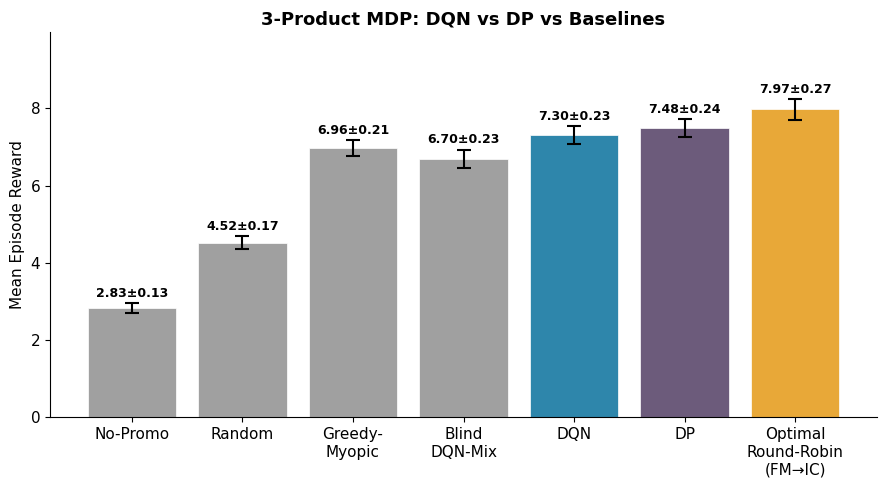

In [142]:
# ── Experiment 1 figure (for article) ──
fig, ax = plt.subplots(figsize=(9, 5))

C_GRAY = "#A0A0A0"
C_BLUE = "#2E86AB"
C_ORANGE = "#E8A838"
C_PURPLE = "#6C5B7B"

r = exp1_results
policies_1_chart = [
    ("No-Promo",                      r["No-Promo"]["mean"],           r["No-Promo"]["se"],           C_GRAY),
    ("Random",                        r["Random"]["mean"],             r["Random"]["se"],             C_GRAY),
    ("Greedy-\nMyopic",               r["Greedy-Myopic"]["mean"],      r["Greedy-Myopic"]["se"],      C_GRAY),
    ("Blind\nDQN-Mix",                r["Blind DQN-mix"]["mean"],      r["Blind DQN-mix"]["se"],      C_GRAY),
    ("DQN",                           r["DQN"]["mean"],                r["DQN"]["se"],                C_BLUE),
    ("DP",                            r["DP"]["mean"],                 r["DP"]["se"],                 C_PURPLE),
    ("Optimal\nRound-Robin\n(FM→IC)", r["Optimal RR (FM→IC)"]["mean"], r["Optimal RR (FM→IC)"]["se"], C_ORANGE),
]

labels = [p[0] for p in policies_1_chart]
means = [p[1] for p in policies_1_chart]
errors = [p[2] for p in policies_1_chart]
colors = [p[3] for p in policies_1_chart]

bars = ax.bar(labels, means, color=colors, edgecolor="white", linewidth=0.5,
              yerr=errors, capsize=5, error_kw={"elinewidth": 1.5, "capthick": 1.5})

for bar, val, err in zip(bars, means, errors):
    label = f"{val:.2f}±{err:.2f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.08,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("3-Product MDP: DQN vs DP vs Baselines", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Episode Reward")
ax.set_ylim(0, max(means) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = Path("../submissions/rl_dp_comparison.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Saved → {save_path}")
plt.show()

## Key Findings

**Memory-unit fix:** The original DP implementation accumulated discount memory in units of δ (proportion = 0.30), but β_m was calibrated against dollar-denominated memory (price × δ). After fixing DP to use the correct units, DP and RL now operate on the same MDP.

**Experiment 1 (3 products, per-category β_m):** With the memory fix, DP can be directly compared to DQN in the RL environment. Both solve the same MDP — DP via exact value iteration on a discretized state space, DQN via function approximation on the continuous state space. The churn-dependent action distribution charts show how each policy adapts its promotion strategy to customer engagement level.

**Experiment 2 (15 products, DP-intractable):** With 5 products per category (16 actions, 31-dim state), DP's state space is ~1.4T — completely intractable. DQN demonstrates cross-category product selection at scale, with churn-dependent promotion behavior that tabular methods cannot reach.

**Remaining DP/RL structural differences:**
- *Churn recovery*: RL resets churn to c₀ on any purchase; DP decrements by η. This makes RL more forgiving of churn buildup.
- *Churn termination*: DP only terminates on no-purchase steps; RL checks every step. Minor impact at low churn levels.
- *Discretization*: DP's 3-bucket memory grid (0.0, 0.9, 2.0) may lose resolution at high fatigue levels where the optimal policy shifts.